In [56]:
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, find_peaks_cwt
import matplotlib.pyplot as plt
import pickle
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.power import TTestPower

with open('/home/metamobility5/Changseob/proj-online_adaptation_GPE/method-torque_profile_generation/torque_splines.pkl', 'rb') as f:
    torque_splines = pickle.load(f)

def upsampling(data, target_length):
    """
    Upsample a 1D numpy array to the desired target length using linear interpolation.
    """
    original_length = len(data)
    original_indices = np.linspace(0, original_length - 1, original_length)
    new_indices = np.linspace(0, original_length - 1, target_length)

    return np.interp(new_indices, original_indices, data)

def upsampling_2d(data, target_length):
    """
    Upsample a 2D numpy array to the desired target length using linear interpolation.
    data: numpy array of shape (n_features, n_samples)
    target_length: desired length of each segment after upsampling
    """
    upsampled_data = np.zeros((data.shape[0], target_length))
    for i in range(data.shape[0]):
        upsampled_data[i, :] = upsampling(data[i, :], target_length)

    return upsampled_data

def segmenting(data, peak_indices, target_length=50, number_of_cycles=None):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    data: numpy array of shape (n_samples, n_features)
    peak_indices: numpy array of shape (n_peak) with start and end indices of each gait cycle
    target_length: desired length of each segment after upsampling
    """
    segments = np.zeros((len(peak_indices) - 1, data.shape[1], target_length))

    for n, (start, end) in enumerate(zip(peak_indices[:-1], peak_indices[1:])):
        for i in range(data.shape[1]):
            segment = data[start:end+1, i]
            segment_upsampled = upsampling(segment, target_length)
            segments[n, i, :] = segment_upsampled
    
    if number_of_cycles is not None:
        segments = segments[:number_of_cycles, :, :]

    return segments # (number_of_cycles, n_features, target_length)

def gait_cycle_generator(peak_indices, num_cycles=None):
    gc_angle_list = []
    gc_polar_x_list = []
    gc_polar_y_list = []

    if num_cycles is None:
        num_cycles = len(peak_indices) - 1
    for i in range(num_cycles):
        start = peak_indices[i]
        end = peak_indices[i + 1]

        for j in range(start, end):
            gc_polar_angle = (j - start) / (end - start) * 2 * np.pi
            gc_angle_list.append(gc_polar_angle)
            gc_polar_x_list.append(np.cos(gc_polar_angle))
            gc_polar_y_list.append(np.sin(gc_polar_angle))

    return np.column_stack((gc_polar_x_list, gc_polar_y_list))

def polar_to_percentage(polar_coords):
    angle = np.arctan2(polar_coords[:, 1], polar_coords[:, 0])
    percentage = (angle + 2*np.pi) % (2 * np.pi) / (2 * np.pi) * 100  # Normalize to (0, 100]
    return percentage

def load_jetson_input_mtr_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    motor_data = df.values
    # 0: timestamp, 1: pos_L, 2: pos_R, 3: vel_L, 4: vel_R, 5: gpio
    if trigger_indices is not None:
        motor_data = motor_data[trigger_indices[0]:trigger_indices[1], :]
    return motor_data

def load_jetson_output_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    output_data = df.values
    # 0: timestamp, 1: gait_phase_L, 2: gait_phase_R, 3: mtr_cmd_L, 4: mtr_cmd_R, 5: gpio_output
    if trigger_indices is not None:
        output_data = output_data[trigger_indices[0]:trigger_indices[1], :]
    return output_data

def load_PC_buffer_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    return df

def detect_heel_strike(GRF_data, threshold, min_interval, max_interval, side, xlim=None):
    # Create binary signal based on threshold
    bi_grf = np.where(GRF_data < threshold, 0, 1)
    diff_grf = np.diff(bi_grf)

    # Find indices where the signal goes from 0 to 1
    heelstrike_index = np.where(diff_grf == 1)[0] + 1
    if heelstrike_index.size == 0:
        return np.array([], dtype=int)

    # Filter out the heel strike indices that are too close or too far apart
    valid_heelstrikes = heelstrike_index[np.insert(np.diff(heelstrike_index) >= min_interval, 0, True)]
    # valid_heelstrikes = valid_heelstrikes[np.insert(np.diff(valid_heelstrikes) <= max_interval, 0, True)]

    # valid_heelstrikes = heelstrike_index[np.insert(np.diff(heelstrike_index) >= min_interval, 0, True)]

    # # Find anomalies in heel strike indices
    # hs_anomaly_idx = np.where(np.diff(valid_heelstrikes)> max_interval)
    # leave_out_gc = hs_anomaly_idx[0].tolist()
    # # Find indices of specific values in numpy array
    # print(f"Leave-out-gait-cycles ({side}): {len(leave_out_gc)}")
    # for gc in leave_out_gc:
    #     closest_index = min(range(len(valid_heelstrikes)), key=lambda i: abs(valid_heelstrikes[i] - valid_heelstrikes[gc]))
    #     # print(f"Closest value: {valid_heelstrikes[closest_index]/100} at index: {closest_index}")

    return valid_heelstrikes

def plot_hs_detection(mtr_data, imu_data, peak_indices, side='R', xlim=None):
    time = mtr_data[:, 0]
    if side == 'R':
        signal = mtr_data[:, 6] # right fsr
    elif side == 'L':
        signal = mtr_data[:, 5] # left fsr

    plt.figure(figsize=(20, 2))
    plt.plot(time, signal, lw=1)
    # pick only peak indices
    plt.plot(time[peak_indices], signal[peak_indices], 'rx', markersize=8, label='peaks')
    print(f"Detected heel strikes at times: {time[peak_indices]}")
    # for idx, peak in enumerate(peak_indices):
    #     plt.text(time[peak], signal[peak], str(signal[peak]), fontsize=8, ha='center', va='bottom')
    prev_div = 0
    # for div in course_dur:
    #     plt.axvline(prev_div + div, color='r', linestyle='--')
    #     prev_div += div
    plt.xlabel('Time (s)')
    plt.ylabel('FSR value')
    plt.title(f'Detected heel strikes {side} side')
    plt.legend()
    plt.show()

def get_prediction_accuracy(predictions, ground_truth, torque_cmd, torque_label, hs_indices, task_segments, leave_out_gc, course_name, course_dur):
    error_list, torque_error_list = [], []
    
    gc_rmse_list, torque_rmse_list = [], []
    for gc in range(len(hs_indices)-1):
        if gc in leave_out_gc:
            error_list.extend([np.nan] * (hs_indices[gc+1] - hs_indices[gc]))
            continue
        start_idx = hs_indices[gc]
        end_idx = hs_indices[gc+1]

        gc_error_list = []
        for i in range(start_idx, end_idx):
            error = ground_truth[i-hs_indices[0]] - predictions[i-hs_indices[0]]
            torque_error = torque_label[i-hs_indices[0]] - torque_cmd[i-hs_indices[0]]
            # torque_error = 1 - torque_cmd[i-hs_indices[0]] / torque_label[i-hs_indices[0]] if torque_label[i-hs_indices[0]] != 0 else 0
            if error < -50:
                error_list.append(error + 100)
                gc_error_list.append(error + 100)
            elif error > 50:
                error_list.append(error - 100)
                gc_error_list.append(error - 100)
            else:
                error_list.append(error)
                gc_error_list.append(error)
            torque_error_list.append(torque_error)
        gc_rmse_list.append(np.sqrt(np.nanmean((np.array(gc_error_list)) ** 2)))
        torque_rmse_list.append(np.sqrt(np.nanmean((np.array(torque_error_list)) ** 2)))
    
    rmse = np.sqrt(np.nanmean((np.array(error_list)) ** 2))

    course_rmse_list, course_rmse_torque_list = [], []
    if course_name <= 3:
        if task_segments is not None:
            for seg in task_segments:
                # seg: (start_time, end_time, incline, speed)
                start_t, end_t = seg[0], seg[1]

                # Find closest HS indices corresponding to time
                # Note: Assuming 100Hz sampling rate roughly matches index/100
                closest_start = hs_indices[np.argmin(np.abs(hs_indices - start_t*100))]
                closest_end = hs_indices[np.argmin(np.abs(hs_indices - end_t*100))]
                
                # Map absolute HS indices to relative error_list indices (offset by first HS)
                idx_start = max(0, closest_start - hs_indices[0])
                idx_end = max(0, closest_end - hs_indices[0])
                
                # Clamp to valid error_list range
                idx_start = min(idx_start, len(error_list))
                idx_end = min(idx_end, len(error_list))

                if idx_start < idx_end:
                    course_error = error_list[idx_start:idx_end]
                    course_torque_error = torque_error_list[idx_start:idx_end]
                    course_rmse_list.append(np.sqrt(np.nanmean((np.array(course_error)) ** 2)))
                    course_rmse_torque_list.append(np.sqrt(np.nanmean((np.array(course_torque_error)) ** 2)))
                else:
                    pass  # No valid data for this segment
    else:    
        # Clamp to valid error_list range
        idx_start = hs_indices[0]
        idx_end = hs_indices[-1]

        if idx_start < idx_end:
            course_error = error_list[idx_start:idx_end]
            course_torque_error = torque_error_list[idx_start:idx_end]
            course_rmse_list.append(np.sqrt(np.nanmean((np.array(course_error)) ** 2)))
            course_rmse_torque_list.append(np.sqrt(np.nanmean((np.array(course_torque_error)) ** 2)))

    # course_rmse_torque_list = course_rmse_torque_list / np.abs(torque_label).max() * 100 # normalize to percentage

    return rmse, course_rmse_list, course_rmse_torque_list, gc_rmse_list, torque_rmse_list, error_list

def plot_gait_phase_prediction(output_data, gait_phase_label, rmse, error_list, course_rmse, hs_indices, segments, start_sec, side, leave_out_gc, xlim=None, condition='adapted'):
    # Plot prediction vs. ground truth
    plt.figure(figsize=(12, 2))
    if condition == 'adapted':
        color = 'gray'
    elif condition == 'pc_buffer':
        color = 'dodgerblue'
    if side == 'L':
        plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, output_data[hs_indices[0]:hs_indices[-1], 1], color=color, label='predicted gait phase', lw=1)
    elif side == 'R':
        plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, output_data[hs_indices[0]:hs_indices[-1], 2], color=color, label='predicted gait phase', lw=1)
    plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, gait_phase_label, lw=1, linestyle='--', color=color, label='gait phase label')
    
    if segments is not None:
        for i, seg in enumerate(segments):
            plt.axvline(seg[1], color='r', linestyle='--')

    for gc in leave_out_gc:
        if gc < len(hs_indices) - 1:
            plt.axvspan(output_data[hs_indices[gc], 0], output_data[hs_indices[gc+1], 0], color='gray', alpha=0.3)
    plt.xlabel('time (s)')
    plt.ylabel('Gait phase (%)')
    plt.title(f'Gait Phase {side} - RMSE: {rmse:.2f} %')
    if xlim is not None: plt.xlim(xlim)
    plt.legend()
    plt.show()

    # # Plot error (gait phase label - predicted)
    # plt.figure(figsize=(40, 5))
    # plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, np.array(error_list), lw=1, linestyle='--', color='g', label='error (gait phase label - predicted)')
    
    # if segments is not None:
    #     for i, seg in enumerate(segments):
    #         # seg: (start_time, end_time, incline, speed)
    #         plt.axvline(seg[1], color='r', linestyle='--')
            
    #         mid_time = (seg[0] + seg[1]) / 2
    #         course_name_str = f"{seg[3]}m/s"
            
    #         plt.text(mid_time, 15, course_name_str, rotation=0, color='r', ha='center', fontsize=20)
    #         if i < len(course_rmse) and not np.isnan(course_rmse[i]):
    #             plt.text(mid_time, 10, f'{course_rmse[i]:.2f}', rotation=0, color='r', ha='center', fontsize=20)

    # for gc in leave_out_gc:
    #     if gc < len(hs_indices) - 1:
    #         plt.axvspan(output_data[hs_indices[gc], 0], output_data[hs_indices[gc+1], 0], color='gray', alpha=0.3)
    # plt.xlabel('time (s)')
    # plt.ylabel('Error (%)')
    # plt.title(f'Gait Phase {side} Error - RMSE: {rmse:.2f} %')
    # plt.axhline(y=0, color='black', linestyle='--')
    # plt.ylim(-20, 20)
    # plt.legend()
    # plt.show()
# ...existing code...

incline_keys = {"RD_5deg": -5, "LG": 0, "RA_5deg": 5}
speed_keys = {"0p4mps": 0.4, "0p6mps": 0.6, "0p8mps": 0.8, "1p0mps": 1.0, "1p2mps": 1.2, "1p4mps": 1.4}

def plot_course_rmses(segments, subjects, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, adapted_rmse_torque_R, adapted_rmse_torque_L, pc_buffer_rmse_torque_R, pc_buffer_rmse_torque_L):

    course_name = []
    for seg in segments:
        spd = 'slow' if seg[3] == 0.3 else 'mid'
        inc = 'LG' if seg[2] == 0 else ('RA' if seg[2] == 10 else 'RD')
        course_name.append(f"{seg[4]}. {inc} - {spd}")

    adapted_rmse = {}
    pc_buffer_rmse = {}
    adapted_rmse_torque = {}
    pc_buffer_rmse_torque = {}
    for subject in subjects:
        adapted_rmse[subject] = np.mean(
            [
                np.asarray(adapted_rmse_R[subject], dtype=float),
                np.asarray(adapted_rmse_L[subject], dtype=float),
            ],
            axis=0
        )
        pc_buffer_rmse[subject] = np.mean(
            [
                np.asarray(pc_buffer_rmse_R[subject], dtype=float),
                np.asarray(pc_buffer_rmse_L[subject], dtype=float),
            ],
            axis=0
        )

    adapted_rmse_avg = np.mean(list(adapted_rmse.values()), axis=0)[:6]
    adapted_rmse_std = np.std(list(adapted_rmse.values()), axis=0)[:6]
    pc_buffer_rmse_avg = np.mean(list(pc_buffer_rmse.values()), axis=0)[:6]
    pc_buffer_rmse_std = np.std(list(pc_buffer_rmse.values()), axis=0)[:6]
    
    fig, ax = plt.subplots(figsize=(4, 2))
    x_pos = np.arange(len(course_name))[:6]

    print(f"Adapted RMSE avg across all tasks: {np.mean(adapted_rmse_avg):.2f} %")
    print(f"PC Buffer RMSE avg across all tasks: {np.mean(pc_buffer_rmse_avg):.2f} %")

    ax.plot(x_pos, adapted_rmse_avg, c = 'k', marker='o',label='Adapted', linewidth=1, linestyle='--')
    ax.fill_between(x_pos, adapted_rmse_avg - adapted_rmse_std, adapted_rmse_avg + adapted_rmse_std, color='k', alpha=0.2)
    ax.plot(x_pos, pc_buffer_rmse_avg, c = 'dodgerblue', marker='o', label='PC Buffer', linewidth=1, linestyle='--')
    ax.fill_between(x_pos, pc_buffer_rmse_avg - pc_buffer_rmse_std, pc_buffer_rmse_avg + pc_buffer_rmse_std, color='dodgerblue', alpha=0.2)

    ax.set_xlabel('Locomotion course (incline - speed)', fontsize=12)
    ax.set_ylabel('Gait phase RMSE (%)', fontsize=12)
    # ax.set_title(f'Course-wise RMSE ({side})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_pos+1, rotation=0)
    # ax.legend(loc='upper left', fontsize=8)
    ax.set_xlim(0, len(course_name[:6])-1)
    ax.set_ylim(0, 22.5)

    plt.tight_layout()
    plt.rcParams['pdf.fonttype'] = 42
    plt.savefig('Course_RMSE_plot.pdf', dpi=300)
    plt.show()


    # # Mean ± std summary across 4 conditions
    # condition_data = {
    #     # "Static": static_rmse,
    #     "Adapted": adapted_rmse,
    #     # "Task Buffer": task_buffer_rmse,
    #     "PC Buffer": pc_buffer_rmse,
    # }

    # torque_condition_data = {
    #     # "Static": static_rmse_torque,
    #     "Adapted": adapted_rmse_torque,
    #     # "Task Buffer": task_buffer_rmse_torque,
    #     "PC Buffer": pc_buffer_rmse_torque,
    # }

    # means, stds, labels = [], [], []; means_torque, stds_torque = [], []
    # for name, values in condition_data.items():
    #     if values is not None and len(values) > 0:
    #         arr = np.asarray(values, dtype=float)
    #         mean_val = np.mean(arr[5-1:]) #np.nanmean(arr)
    #         mean_val_torque = np.mean(np.asarray(torque_condition_data[name], dtype=float)[5-1:]) #np.nanmean(np.asarray(torque_condition_data[name], dtype=float))
    #         std_val = 0 #np.nanstd(arr)
    #         std_val_torque = 0 #np.nanstd(np.asarray(torque_condition_data[name], dtype=float))
    #         print(f"{name} ({side}) -> mean: {mean_val:.2f}, std: {std_val:.2f}, mean torque: {mean_val_torque:.2f}, std torque: {std_val_torque:.2f}")
    #     else:
    #         mean_val = np.nan; mean_val_torque = np.nan
    #         std_val = np.nan; std_val_torque = np.nan
    #         print(f"{name} ({side}) -> mean: nan, std: nan, mean torque: nan, std torque: nan")

    #     labels.append(name)
    #     means.append(mean_val); means_torque.append(mean_val_torque)
    #     stds.append(std_val); stds_torque.append(std_val_torque)

    # # Assuming labels, means, stds, means_torque, and stds_torque are already defined
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    # x_cond = np.arange(len(labels))
    # colors = ['k', 'm', 'r', 'b']

    # # Subplot 1: Gait phase RMSE
    # ax1.bar(
    #     x_cond,
    #     np.nan_to_num(means, nan=0.0),
    #     yerr=np.nan_to_num(stds, nan=0.0),
    #     capsize=5,
    #     color=colors,
    #     alpha=0.8
    # )
    # ax1.set_xticks(x_cond)
    # ax1.set_xticklabels(labels, rotation=00)
    # ax1.set_ylabel('Gait phase RMSE (%)')
    # ax1.set_xlabel('Condition')
    # ax1.set_ylim(0, 10)
    # ax1.set_title('Gait Phase Accuracy')

    # # Subplot 2: Torque RMSE
    # ax2.bar(
    #     x_cond,
    #     np.nan_to_num(means_torque, nan=0.0),
    #     yerr=np.nan_to_num(stds_torque, nan=0.0),
    #     capsize=5,
    #     color=colors,
    #     alpha=0.8
    # )
    # ax2.set_xticks(x_cond)
    # ax2.set_xticklabels(labels, rotation=00)
    # ax2.set_ylabel('Torque RMSE ($N \cdot m$)')
    # ax2.set_xlabel('Condition')
    # ax2.set_title('Torque Tracking Accuracy')

    # plt.tight_layout()
    # plt.show()

def plot_course_rmses_2(subjects, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, data='gc'):
    adapted_rmse = {}
    pc_buffer_rmse = {}
    for subject in subjects:
        adapted_rmse[subject] = np.mean([
            np.asarray(adapted_rmse_R[subject], dtype=float),
            np.asarray(adapted_rmse_L[subject], dtype=float)
        ], axis=0)
        pc_buffer_rmse[subject] = np.mean([
            np.asarray(pc_buffer_rmse_R[subject], dtype=float),
            np.asarray(pc_buffer_rmse_L[subject], dtype=float)
        ], axis=0)

    def summarize_subject_group(rmse_dict, indices):
        per_subject = []
        for subject in subjects:
            arr = np.asarray(rmse_dict[subject], dtype=float)
            per_subject.append(np.nanmean(arr[indices]) if arr.size > max(indices) else np.nan)
        return np.asarray(per_subject, dtype=float)

    cond_names = ['LG_Diff', 'RA_Same', 'RA_Diff', 'RD_Same', 'RD_Diff']
    indices = [[7, 13], [8, 15], [9, 14], [10, 17], [11, 16]]

    print("Subjects where adapted RMSE < pc_buffer RMSE (averaged across all courses and sides):")
    for condition in cond_names:
        print(f"\nCondition: {condition}")
        for subject in subjects:
            idx = indices[cond_names.index(condition)]
            a = np.nanmean(np.asarray(adapted_rmse[subject][idx], dtype=float))
            p = np.nanmean(np.asarray(pc_buffer_rmse[subject][idx], dtype=float))
            if a < p:
                print(f"{subject}: adapted={a:.1f}, pc_buffer={p:.1f}, difference={a-p:.3f}")

    data_list = []
    condition_arrays = {}
    for name, idx in zip(cond_names, indices):
        a_vals = summarize_subject_group(adapted_rmse, idx)
        p_vals = summarize_subject_group(pc_buffer_rmse, idx)
        condition_arrays[name] = {'Adapted': a_vals, 'PC_buffer': p_vals}

        for val in a_vals:
            data_list.append({'RMSE': val, 'Method': 'Adapted', 'Condition': name})
        for val in p_vals:
            data_list.append({'RMSE': val, 'Method': 'PC_buffer', 'Condition': name})

    df = pd.DataFrame(data_list).dropna()
    model = ols('RMSE ~ C(Method) + C(Condition) + C(Method):C(Condition)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\n--- TWO-WAY ANOVA RESULTS ---")
    print(anova_table)

    posthoc_p_values = {}
    num_tests = len(cond_names)
    power_calc = TTestPower()
    print("\n--- POWER ANALYSIS (Target: 80% Power, Bonferroni Alpha = 0.01) ---")

    for name in cond_names:
        a = condition_arrays[name]['Adapted']
        p = condition_arrays[name]['PC_buffer']
        _, p_raw = stats.ttest_rel(a, p, nan_policy='omit')
        p_corrected = 1.0 if np.isnan(p_raw) else min(1.0, p_raw * num_tests)
        posthoc_p_values[name] = p_corrected

        differences = a - p
        mean_diff = np.nanmean(differences)
        std_diff = np.nanstd(differences, ddof=1)
        if not np.isfinite(std_diff) or std_diff == 0:
            continue

        cohen_dz = mean_diff / std_diff
        try:
            required_n = power_calc.solve_power(
                effect_size=cohen_dz,
                alpha=0.01,
                power=0.80,
                alternative='two-sided'
            )
            print(f"Condition: {name: <15} | Cohen's dz: {cohen_dz: >5.2f} | Required N: {np.ceil(required_n):.0f}")
        except ValueError:
            print(f"Condition: {name: <15} | Effect size too small to reliably calculate N.")

    fig, axes = plt.subplots(1, 5, figsize=(12, 3), sharey=False)
    rng = np.random.default_rng(42)
    subject_cmap = plt.get_cmap('tab10', len(subjects))
    subject_colors = {subject: subject_cmap(i) for i, subject in enumerate(subjects)}

    def draw_bar_with_subject_scatter(ax, title, cond_key, show_ylabel=False):
        a_vals = condition_arrays[cond_key]['Adapted']
        p_vals = condition_arrays[cond_key]['PC_buffer']

        a_mean, a_std = np.nanmean(a_vals), np.nanstd(a_vals)
        p_mean, p_std = np.nanmean(p_vals), np.nanstd(p_vals)

        x = np.array([0, 1])
        ax.bar(x, [a_mean, p_mean], yerr=[a_std, p_std], color=['k', 'dodgerblue'], alpha=0.6, capsize=5, width=0.6)

        jitter = rng.uniform(-0.2, 0.2, len(subjects))
        for i, subject in enumerate(subjects):
            color = subject_colors[subject]
            if np.isfinite(a_vals[i]) and np.isfinite(p_vals[i]):
                ax.plot([x[0] + jitter[i], x[1] + jitter[i]], [a_vals[i], p_vals[i]], color=color, alpha=0.35, linewidth=1, zorder=2)
            if np.isfinite(a_vals[i]):
                ax.scatter(x[0] + jitter[i], a_vals[i], s=35, facecolors=[color], edgecolors='none', linewidths=0.5, zorder=3, alpha=0.7)
            if np.isfinite(p_vals[i]):
                ax.scatter(x[1] + jitter[i], p_vals[i], s=35, facecolors=[color], edgecolors='none', linewidths=0.5, zorder=3, alpha=0.7)

        p_corr = posthoc_p_values[cond_key]
        if p_corr < 0.001:
            sig_text = '***'
        elif p_corr < 0.01:
            sig_text = '**'
        elif p_corr < 0.05:
            sig_text = '*'
        # else:
        #     sig_text = f'(p={p_corr:.2f})'

        valid_vals = np.concatenate([a_vals[np.isfinite(a_vals)], p_vals[np.isfinite(p_vals)]])
        max_y = (np.max(valid_vals) if valid_vals.size else 0) + 0.0
        if p_corr < 0.05:
            ax.plot([0, 0, 1, 1], [max_y, max_y*1.05, max_y*1.05, max_y], lw=1, color='black')
            ax.text(0.5, max_y*1.05, sig_text, ha='center', va='bottom', color='black', fontsize=12)

        ax.set_title(title, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['Adapted\nw/o replay', 'Manifold-aware\nreplay'])
        if show_ylabel:
            ax.set_ylabel('Gait phase RMSE (%)') if data == 'gc' else ax.set_ylabel('Torque RMSE (N-m)')
        # ax.set_ylim(0, max_y * 1.2)
        # if data is not 'gc':
        #     for j in [0, 3, 4]:
        #         axes[j].set_ylim(0, 3)
        #     for j in [1, 2]:
        #         axes[j].set_ylim(0, 7.5)
        from matplotlib.ticker import MaxNLocator
        for j in range(5):
            axes[j].yaxis.set_major_locator(MaxNLocator(nbins=3))   # about 4 major ticks
        # ax.set_ylim(0, 13 if data == 'gc' else 3)

        return a_mean, a_std, p_mean, p_std
        

    titles = ['LG, Different speed', 'LG to RA, Same speed', 'LG to RA, Different speed', 'LG to RD, Same speed', 'LG to RD, Different speed']
    a_means, a_stds, p_means, p_stds = [], [], [], []
    for i, (name, title) in enumerate(zip(cond_names, titles)):
        a_mean, a_std, p_mean, p_std = draw_bar_with_subject_scatter(axes[i], title, name, show_ylabel=(i == 0))
        a_means.append(a_mean); a_stds.append(a_std); p_means.append(p_mean); p_stds.append(p_std)
    
    a_means_arr = np.array(a_means);    a_stds_arr = np.array(a_stds)
    p_means_arr = np.array(p_means);    p_stds_arr = np.array(p_stds)
    print(f'Adapted means: {[f"{mean:.2f} ± {std:.2f}" for (mean, std) in zip(a_means_arr, a_stds_arr)]}')
    print(f'PC Buffer means: {[f"{mean:.2f} ± {std:.2f}" for (mean, std) in zip(p_means_arr, p_stds_arr)]}')
    pct_diff = (a_means_arr - p_means_arr) / p_means_arr * 100
    print(f'Mean percentage difference (Adapted - PC Buffer): {[f"{x:.2f}" for x in pct_diff]}')
    print(f'Mean Adapted: {np.mean(a_means):.2f} Mean PC Buffer: {np.mean(p_means):.2f}')
    print(f'Overall mean percentage difference: {((np.mean(a_means) - np.mean(p_means)) / np.mean(p_means) * 100):.2f}%')

    from matplotlib.lines import Line2D
    subject_handles = [
        Line2D([0], [0], marker='o', color='w', label=subject, markerfacecolor=subject_colors[subject], markersize=6, markeredgecolor='none', markeredgewidth=0, alpha=0.7)
        for subject in subjects
    ]
    fig.legend(handles=subject_handles, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=len(subjects), frameon=False, title='Subjects')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.rcParams['pdf.fonttype'] = 42
    plt.savefig('Torque_RMSE_plot.pdf', dpi=300)
    plt.show()
    
def process_representative_rmse(subjects, rmse_R, rmse_L, hs_indices, data = 'gc'):
    condition_map = {
    "LG - Different Speed": (7, 13),
    "LG to RA - Same Speed": (8, 15),
    "LG to RA - Different Speed": (9, 14),
    "LG to RD - Same Speed": (10, 17),
    "LG to RD - Different Speed": (11, 16),
    }

    # Store three representative trajectories per condition.
    # Each case is selected from Adapted scores, then matched to the same
    # subject/side/course in PC Buffer for fair comparison.
    gc_rmse_cases_per_condition = {}
    hs_idx_cases_per_condition = {}
    all_y_vals = []

    case_order = ['H', 'M', 'L']

    fig, axes = plt.subplots(1, 15, figsize=(12, 3), sharex=True, sharey=True)

    for cond_col, (condition, (idx1, idx2)) in enumerate(condition_map.items()):
        print(f"\nCondition: {condition}")
        all_candidates = []
        for subject in subjects:
            for side_sel, rmse_side in [('R', rmse_R), ('L', rmse_L)]:
                for course_idx in [idx1, idx2]:
                    curve = rmse_side['adapted'][subject][course_idx]
                    score = np.nanmean(np.asarray(curve, dtype=float))
                    if np.isfinite(score):
                        all_candidates.append({
                            'subject': subject,
                            'side': side_sel,
                            'course_idx': course_idx,
                            'score': score,
                            'adapted_curve': list(curve),
                            'adapted_hs': list(hs_indices['adapted'][subject][course_idx] / 100),
                        })

        if len(all_candidates) == 0:
            print("No finite candidates found for this condition.")
            continue

        all_candidates = sorted(all_candidates, key=lambda x: x['score'])
        selected_idx = {
            'L': 0,
            'M': len(all_candidates) // 2,
            'H': len(all_candidates) - 1,
        }

        gc_rmse_cases_per_condition[condition] = {}
        hs_idx_cases_per_condition[condition] = {}

        for case_col, case_name in enumerate(case_order):
            ax_idx = cond_col * 3 + case_col
            ax = axes[ax_idx]
            case = all_candidates[selected_idx[case_name]]

            subject_sel = case['subject']
            side_sel = case['side']
            course_idx_sel = case['course_idx']

            adapted_curve = case['adapted_curve']
            adapted_hs = case['adapted_hs']
            adapted_min_len = min(len(adapted_curve), len(adapted_hs))

            if side_sel == "R":
                pc_curve = list(rmse_R['pc_buffer'][subject_sel][course_idx_sel])
            else:
                pc_curve = list(rmse_L['pc_buffer'][subject_sel][course_idx_sel])
            pc_hs = list(hs_indices['pc_buffer'][subject_sel][course_idx_sel] / 100)
            pc_min_len = min(len(pc_curve), len(pc_hs))

            gc_rmse_cases_per_condition[condition][case_name] = {
                'adapted': adapted_curve[:adapted_min_len],
                'pc_buffer': pc_curve[:pc_min_len],
            }
            all_y_vals.extend([v for v in gc_rmse_cases_per_condition[condition][case_name]['adapted'] if np.isfinite(v)])
            all_y_vals.extend([v for v in gc_rmse_cases_per_condition[condition][case_name]['pc_buffer'] if np.isfinite(v)])
            hs_idx_cases_per_condition[condition][case_name] = {
                'adapted': adapted_hs[:adapted_min_len],
                'pc_buffer': pc_hs[:pc_min_len],
            }

            print(
                f"{case_name:>7}",
                subject_sel,
                side_sel,
                course_idx_sel,
                f"score={case['score']:.3f}",
                len(hs_idx_cases_per_condition[condition][case_name]['adapted']),
                len(hs_idx_cases_per_condition[condition][case_name]['pc_buffer']),
            )

            ax.plot(
                hs_idx_cases_per_condition[condition][case_name]['adapted'],
                gc_rmse_cases_per_condition[condition][case_name]['adapted'],
                color='k',
                linestyle='-',
                alpha=0.85,
                marker='o',
                markersize=2.5,
                linewidth=1,
                label='Adapted',
            )
            ax.plot(
                hs_idx_cases_per_condition[condition][case_name]['pc_buffer'],
                gc_rmse_cases_per_condition[condition][case_name]['pc_buffer'],
                color='dodgerblue',
                linestyle='-',
                alpha=0.85,
                marker='o',
                markersize=2.5,
                linewidth=1,
                label='PC Buffer',
            )

            ax.set_title(condition if case_col == 1 else '')
            ax.set_xlabel(case_name.capitalize())

        # ax.set_yticks([0, 10, 20, 30])
    if len(all_y_vals) > 0:
        y_min = float(np.min(all_y_vals))
        y_max = float(np.max(all_y_vals))
        if np.isclose(y_min, y_max):
            y_pad = max(0.5, abs(y_min) * 0.1)
        else:
            y_pad = (y_max - y_min) * 0.05
        y_lower = y_min - y_pad
        y_upper = y_max + y_pad
        y_ticks = np.linspace(y_lower, y_upper, 4)
        for ax in axes:
            ax.set_ylim(y_lower, y_upper)
            # ax.set_yticks(y_ticks)
    if data == 'gc':
        axes[0].set_ylabel('Gait Phase RMSE (%)')
        axes[0].set_xlim(-1, 8)
        axes[0].set_ylim(0, 35)
        axes[0].set_xticks([])
        axes[0].set_yticks([0, 10, 20, 30])
    else:
        axes[0].set_ylabel('Torque RMSE (N-m)')
        axes[0].set_xlim(-1, 8)
        axes[0].set_ylim(0, 6)
        axes[0].set_xticks([])
        axes[0].set_yticks([0, 2, 4, 6])

    for j in range(0, 15):
        axes[j].spines['right'].set_visible(False)
        axes[j].spines['top'].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    # Keep each 3-panel condition cluster tight, and add larger gaps between clusters.
    left, right = 0.04, 0.995
    bottom, top = 0.23, 0.86
    small_gap = 0.004
    large_gap = 0.06
    total_w = right - left
    total_gap = 10 * small_gap + 4 * large_gap
    ax_w = (total_w - total_gap) / 15
    ax_h = top - bottom

    for i, ax in enumerate(axes):
        large_before = i // 3
        small_before = i - large_before
        x = left + i * ax_w + small_before * small_gap + large_before * large_gap
        ax.set_position([x, bottom, ax_w, ax_h])
    
    if data == 'gc':    
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig('Representative_gc.pdf', dpi=300)
        plt.show()
    else:
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig('Representative_torque.pdf', dpi=300)
        plt.show()


def plot_gc_rmses(segments, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, side='Overall'):
    def _build_course_curves(r_courses, l_courses):
        course_curves = []

        for r_curve, l_curve in zip(r_courses, l_courses):
            r_curve = np.asarray(r_curve, dtype=float)
            l_curve = np.asarray(l_curve, dtype=float)

            if side == 'R':
                course_curve = r_curve
            elif side == 'L':
                course_curve = l_curve
            else:
                n = min(len(r_curve), len(l_curve))
                course_curve = (
                    np.nanmean(np.vstack([r_curve[:n], l_curve[:n]]), axis=0)
                    if n > 0 else np.array([], dtype=float)
                )

            course_curves.append(course_curve)

        unfolded = np.concatenate([c for c in course_curves if len(c) > 0]) if any(len(c) > 0 for c in course_curves) else np.array([], dtype=float)
        return course_curves, unfolded

    adapted_courses, adapted_unfolded = _build_course_curves(adapted_rmse_R, adapted_rmse_L)
    pc_courses, pc_unfolded = _build_course_curves(pc_buffer_rmse_R, pc_buffer_rmse_L)

    n_courses = min(len(segments), len(adapted_courses), len(pc_courses))
    display_lengths = [
        int(round(np.mean([len(adapted_courses[i]), len(pc_courses[i])])))
        for i in range(n_courses)
    ]
    boundaries = np.concatenate([[0], np.cumsum(display_lengths)])
    centers = (boundaries[:-1] + boundaries[1:]) / 2
    course_labels = [
        f"{seg[4]}" if len(seg) > 4 else str(i + 1)
        for i, seg in enumerate(segments[:n_courses])
    ]

    plt.figure(figsize=(16, 4), dpi=200)
    plt.plot(np.arange(len(adapted_unfolded)), adapted_unfolded, color='k', lw=1, label='Adapted', marker='o', markersize=2.5, linestyle='-')
    plt.plot(np.arange(len(pc_unfolded)), pc_unfolded, color='dodgerblue', lw=1, label='PC Buffer', marker='o', markersize=2.5, linestyle='-')

    for boundary in boundaries:
        plt.axvline(boundary, color='gray', linestyle=':', linewidth=1, alpha=0.7)

    plt.xticks(centers, course_labels)
    plt.xlabel('Sequential gait cycles across 18 courses')
    plt.ylabel('Gait phase RMSE (%)')
    plt.title(f'Unfolded gait-cycle RMSE ({subject}, {side})')
    plt.ylim(0, 30)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_torque(torque_cmd, torque_label, side='L', condition='adapted'):
    plt.figure(figsize=(12, 2))
    if side == 'L':
        plt.plot(torque_cmd, lw=1, label='Torque Command', color='gray' if condition == 'adapted' else 'dodgerblue')
    elif side == 'R':
        plt.plot(torque_cmd, lw=1, label='Torque Command', color='gray' if condition == 'adapted' else 'dodgerblue')
    plt.plot(torque_label, lw=1, label='Torque Label', color='gray' if condition == 'adapted' else 'dodgerblue', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Torque (N-m)')
    plt.legend()
    plt.show()

def plot_positive_power(angular_velocity, torque_cmd):
    power = -angular_velocity * torque_cmd
    positive_power = np.where(power > 0, power, 0)

    work = np.sum(power) / 100  # Assuming 100 Hz sampling rate, convert to Joules 
    positive_work = np.sum(positive_power) / 100  # Assuming 100 Hz sampling rate, convert to Joules
    print(f"Positive work done: {positive_work:.2f} J")

    plt.figure(figsize=(30, 4))
    plt.plot(power, lw=1, label='Power', color='green', linestyle='--')
    plt.plot(positive_power, lw=1, label='Positive Power', color='orange')
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.legend()
    plt.show()

    return work, positive_work

def plot_imu_saggital(imu_data):
    plt.figure(figsize=(30, 4))
    plt.plot(imu_data[:, 0], imu_data[:, 3], lw=1, label='L_Acc_Z', color='blue')
    plt.plot(imu_data[:, 0], imu_data[:, 9], lw=1, label='R_Acc_Z', color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('IMU acc (m/s²)')
    plt.legend()
    plt.show()

def plot_jerk(imu_data):
    jerk_L = np.diff(imu_data[:, 3]) * 100  # L_Acc_Z
    jerk_R = np.diff(imu_data[:, 9]) * 100  # R_Acc_Z

    plt.figure(figsize=(30, 4))
    plt.plot(imu_data[1:, 0], jerk_L, lw=1, label='L_Acc_Jerk', color='blue')
    plt.plot(imu_data[1:, 0], jerk_R, lw=1, label='R_Acc_Jerk', color='red')
    plt.xlim(40, 60)
    plt.ylim(-1000, 1000)
    plt.xlabel('Time (s)')
    plt.ylabel('IMU acc jerk (m/s³)')
    plt.legend()
    plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
import os
import shutil
from IPython.display import HTML

def gait_phase_video(output_data, gait_phase_label, hs_indices, start_sec, side,
                     condition='adapted', fps=30, save_path=None,
                     fig_size=(2.25, 2.25), dpi=200, bitrate=6000):
    color = 'dodgerblue' if condition == 'pc_buffer' else 'gray'
    t = output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec
    col = 1 if side == 'L' else 2
    pred = output_data[hs_indices[0]:hs_indices[-1], col]
    gt = np.asarray(gait_phase_label)[:len(t)]

    window_sec = 2.0
    fs = 1.0 / np.median(np.diff(t))
    window_n = max(1, int(round(fs * window_sec)))
    step = max(1, int(round(fs / fps)))
    n_frames = max(1, (len(t) - 1) // step + 1)

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    line_pred, = ax.plot([], [], color=color, lw=1.5, label='Pred')
    line_gt, = ax.plot([], [], color=color, lw=1.5, ls='--', label='GT')

    font_name = 'sans-serif'
    label_size, tick_size, legend_size = 10, 9, 10

    ax.set_ylim(0, 100)
    ax.set_xlabel('Time (s)', fontsize=label_size, fontname=font_name)
    ax.set_yticks([0, 100])
    ax.set_ylabel('Gait phase (%)', fontsize=label_size, fontname=font_name)

    ax.tick_params(axis='both', labelsize=tick_size)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname(font_name)

    legend = ax.legend(loc='lower center', bbox_to_anchor=(0.4, 1.02), ncol=2,
                       fontsize=legend_size, frameon=False)
    for text in legend.get_texts():
        text.set_fontname(font_name)

    fig.tight_layout()

    def update(frame):
        i1 = min((frame + 1) * step, len(t))
        i0 = max(0, i1 - window_n)

        t_w = t[i0:i1]
        pred_w = pred[i0:i1]
        gt_w = gt[i0:i1]

        line_pred.set_data(t_w, pred_w)
        line_gt.set_data(t_w, gt_w)

        if len(t_w) > 0:
            ax.set_xlim(t_w[-1] - window_sec, t_w[-1])

        ax.set_ylim(0, 100)
        return line_pred, line_gt

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    plt.close(fig)

    if save_path:
        ext = os.path.splitext(save_path)[1].lower()
        if ext != '.mp4':
            save_path = os.path.splitext(save_path)[0] + '.mp4'
        if not shutil.which('ffmpeg'):
            raise RuntimeError("ffmpeg not found. Install it with: conda install -c conda-forge ffmpeg")
        anim.save(save_path, writer='ffmpeg', fps=fps, dpi=dpi, bitrate=bitrate)
        print(f"Saved to {save_path}")
    else:
        return HTML(anim.to_jshtml(fps=fps))

def torque_video(torque_cmd, torque_label, t, side='L', condition='adapted', fps=30, 
                 save_path=None, fig_size=(2.25, 2.25), dpi=200, bitrate=6000):
    color = 'dodgerblue' if condition == 'pc_buffer' else 'gray'
    cmd = np.asarray(torque_cmd)
    label = np.asarray(torque_label)
    t = np.asarray(t)

    window_sec = 2.0
    fs = 1.0 / np.median(np.diff(t))
    window_n = max(1, int(round(fs * window_sec)))
    step = max(1, int(round(fs / fps)))
    n_frames = max(1, (len(t) - 1) // step + 1)

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    line_cmd, = ax.plot([], [], color=color, lw=1.5, label='Command')
    line_label, = ax.plot([], [], color=color, lw=1.5, ls='--', label='Label')

    font_name = 'sans-serif'
    label_size, tick_size, legend_size = 10, 9, 10

    y_min, y_max = min(np.min(cmd), np.min(label)), max(np.max(cmd), np.max(label))
    ax.set_ylim(y_min - 2, y_max + 2)
    ax.set_xlabel('Time (s)', fontsize=label_size, fontname=font_name)
    ax.set_ylabel('Torque (N·m)', fontsize=label_size, fontname=font_name)

    ax.tick_params(axis='both', labelsize=tick_size)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontname(font_name)

    legend = ax.legend(loc='lower center', bbox_to_anchor=(0.4, 1.02), ncol=2,
                       fontsize=legend_size, frameon=False)
    for text in legend.get_texts():
        text.set_fontname(font_name)

    fig.tight_layout()

    def update(frame):
        i1 = min((frame + 1) * step, len(t))
        i0 = max(0, i1 - window_n)

        t_w = t[i0:i1]
        cmd_w = cmd[i0:i1]
        label_w = label[i0:i1]

        line_cmd.set_data(t_w, cmd_w)
        line_label.set_data(t_w, label_w)

        if len(t_w) > 0:
            ax.set_xlim(t_w[-1] - window_sec, t_w[-1])

        return line_cmd, line_label

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    plt.close(fig)

    if save_path:
        ext = os.path.splitext(save_path)[1].lower()
        if ext != '.mp4':
            save_path = os.path.splitext(save_path)[0] + '.mp4'
        if not shutil.which('ffmpeg'):
            raise RuntimeError("ffmpeg not found. Install it with: conda install -c conda-forge ffmpeg")
        anim.save(save_path, writer='ffmpeg', fps=fps, dpi=dpi, bitrate=bitrate)
        print(f"Saved to {save_path}")
    else:
        return HTML(anim.to_jshtml(fps=fps))


def bin_video(start_idx, input_reduced, task_labels, course_labels=None, current_course=None,
              side='R', fps=10, speed=1, save_path=None, fig_size=(2, 2),
              dpi=200, bitrate=6000, sample_rate=100,
              xlim=None, ylim=None, zlim=None):
    """Animate replay-buffer accumulation in 3-D PC space (PC1 x PC2 x PC3).

    Past-course bins are pre-loaded as a faded static background. Only the
    current-course bins are animated, appearing at their real timestamps.

    Parameters
    ----------
    start_idx : list[int]
        Global sample index (at `sample_rate` Hz) when each entry was stacked.
    input_reduced : list
        3-D PCA coordinates per stacked sample, as "[x y z]" strings or arrays.
    task_labels : list[str]
        Task label (e.g. "LG_slow") for each entry.
    course_labels : list[str] or None
        Course identifier for each entry. Past-course entries become a faded
        static background; only `current_course` entries are animated.
    current_course : str or None
        The course being animated (e.g. "8_1").
    side : str
        'L' or 'R', shown in the title.
    fps : int
        Output frame rate.
    speed : float
        Playback speed multiplier. `speed=10` means 10 real seconds = 1 video
        second, so a 300 s course produces a 30 s video. Increase to compress,
        decrease to slow down.
    save_path : str or None
        If given, saves as MP4; otherwise returns an HTML widget.
    sample_rate : int
        Samples per second used to convert start_idx -> wall-clock seconds.
    """
    from matplotlib.lines import Line2D
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    def _parse_pt(p):
        if isinstance(p, str):
            arr = np.fromstring(p.strip().strip('[]').replace(',', ' '), sep=' ')
        else:
            arr = np.asarray(p, dtype=float).ravel()
        return arr if arr.size >= 3 and np.all(np.isfinite(arr[:3])) else None

    pairs = []
    for i, (idx, pt, lbl) in enumerate(zip(start_idx, input_reduced, task_labels)):
        arr = _parse_pt(pt)
        if arr is not None:
            cl = course_labels[i] if course_labels is not None else None
            pairs.append((int(idx), arr, lbl, cl))

    if not pairs:
        print("bin_video: no valid data points.")
        print(f"  len(input_reduced)={len(input_reduced)}, len(start_idx)={len(start_idx)}, len(task_labels)={len(task_labels)}")
        if input_reduced:
            print(f"  first input_reduced value: {repr(input_reduced[0])[:120]}")
        return

    pairs.sort(key=lambda x: x[0])

    if course_labels is not None and current_course is not None:
        past_pairs = [(idx, arr, lbl) for idx, arr, lbl, cl in pairs if cl != current_course]
        curr_pairs = [(idx, arr, lbl) for idx, arr, lbl, cl in pairs if cl == current_course]
    else:
        past_pairs = []
        curr_pairs = [(idx, arr, lbl) for idx, arr, lbl, _ in pairs]

    if not curr_pairs:
        print(f"bin_video: no data points for current_course={current_course!r}.")
        return

    all_pts   = np.array([p[1][:3] for p in past_pairs + curr_pairs])
    past_pts  = np.array([p[1][:3] for p in past_pairs]) if past_pairs else np.empty((0, 3))
    past_lbls = [p[2] for p in past_pairs]

    curr_pairs.sort(key=lambda x: x[0])
    curr_times = np.array([p[0] for p in curr_pairs])
    curr_pts   = np.array([p[1][:3] for p in curr_pairs])
    curr_lbls  = [p[2] for p in curr_pairs]

    all_lbls     = past_lbls + curr_lbls
    unique_tasks = list(dict.fromkeys(all_lbls))
    cmap_fn      = ["#0016BF", '#1f77b4', '#d62728', "#e700e3",  "#014708", '#2ca02c',].__getitem__
    task_colors  = {t: cmap_fn(i % 10) for i, t in enumerate(unique_tasks)}
    curr_colors  = np.array([task_colors[l] for l in curr_lbls])

    # Real elapsed time within the current course
    t_secs   = (curr_times - curr_times[0]) / sample_rate
    real_dur = t_secs[-1] if len(t_secs) > 1 else 0.0
    # Video duration scales with real duration via speed multiplier
    n_frames = int(real_dur / speed * fps) + 2   # +2 ensures last point is shown
    n_pts    = len(curr_pairs)

    print(f"bin_video: {len(past_pairs)} past pts (background) + {n_pts} current pts | "
          f"real_dur={real_dur:.1f}s | video={real_dur/speed:.1f}s @ {fps}fps ({n_frames} frames)")

    pad = 0.10
    def _lim(col):
        lo, hi = all_pts[:, col].min(), all_pts[:, col].max()
        m = (hi - lo or 1.0) * pad
        return lo - m, hi + m
    xlim, ylim, zlim = xlim, ylim, zlim

    font_name, label_sz, tick_sz = 'sans-serif', 9, 8

    fig = plt.figure(figsize=fig_size, dpi=dpi)
    ax  = fig.add_subplot(111, projection='3d')

    # Static background: past-course bins (faded)
    if len(past_pts) > 0:
        for task in unique_tasks:
            mask = np.array([l == task for l in past_lbls])
            if np.any(mask):
                ax.scatter(past_pts[mask, 0], past_pts[mask, 1], past_pts[mask, 2],
                           s=7, color=task_colors[task], depthshade=False, zorder=2)

    empty = np.array([])
    scat     = ax.scatter(empty, empty, empty, s=7, depthshade=False, zorder=3)
    scat_new = ax.scatter(empty, empty, empty, s=7, depthshade=False, zorder=4)

    ax.set_xlim(*(xlim if xlim is not None else _lim(0)))
    ax.set_ylim(*(ylim if ylim is not None else _lim(1)))
    ax.set_zlim(*(zlim if zlim is not None else _lim(2)))
    title_course = f' — course {current_course}' if current_course else ''
    ax.tick_params(axis='both', labelsize=tick_sz)
    ax.view_init(elev=30, azim=-45)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.grid(False)

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=task_colors[t], markersize=5, label=t)
               for t in unique_tasks]
    # ax.legend(handles=handles, fontsize=tick_sz - 1, frameon=False, loc='upper left')
    fig.tight_layout()

    n_past = len(past_pairs)

    def update(frame):
        current_real = (frame / fps) * speed
        n     = int(np.searchsorted(t_secs, current_real, side='right'))
        n     = max(1, min(n, n_pts))
        prev_real = ((frame - 1) / fps) * speed if frame > 0 else -1.0
        n_prev = int(np.searchsorted(t_secs, prev_real, side='right')) if frame > 0 else 0
        n_prev = min(n_prev, n)

        scat._offsets3d = (curr_pts[:n, 0], curr_pts[:n, 1], curr_pts[:n, 2])
        scat.set_color(curr_colors[:n])

        if n_prev < n:
            scat_new._offsets3d = (curr_pts[n_prev:n, 0],
                                   curr_pts[n_prev:n, 1],
                                   curr_pts[n_prev:n, 2])
            scat_new.set_color(curr_colors[n_prev:n])
        else:
            scat_new._offsets3d = (empty, empty, empty)

        return scat, scat_new,
    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    plt.close(fig)

    if save_path:
        if not save_path.endswith('.mp4'):
            save_path = os.path.splitext(save_path)[0] + '.mp4'
        if not shutil.which('ffmpeg'):
            raise RuntimeError("ffmpeg not found. Install it with: conda install -c conda-forge ffmpeg")
        anim.save(save_path, writer='ffmpeg', fps=fps, dpi=dpi, bitrate=bitrate)
        print(f"Saved to {save_path}")
    else:
        return HTML(anim.to_jshtml(fps=fps))
    




def grid_key_video(start_idx, grid_key, task_labels, course_labels=None, current_course=None,
                   side='R', fps=10, speed=1, save_path=None, fig_size=(2, 2),
                   dpi=200, bitrate=6000, sample_rate=100,
                   xlim=None, ylim=None, zlim=None):
    """Same as bin_video but for discrete grid-key coordinates ("(-9, -1, 13)" format).

    Pre-parses the grid-key strings into arrays then delegates entirely to
    bin_video so that plotting style, speed, and timing are always identical.
    Axis limits default to auto-computed from the grid-key data range.
    """
    def _parse_grid(p):
        try:
            if isinstance(p, str):
                return np.fromstring(p.strip('()').replace(',', ' '), sep=' ')
            return np.asarray(p, dtype=float).ravel()
        except Exception:
            return np.array([])

    parsed = [_parse_grid(p) for p in grid_key]
    return bin_video(start_idx, parsed, task_labels,
                     course_labels=course_labels, current_course=current_course,
                     side=side, fps=fps, speed=speed, save_path=save_path,
                     fig_size=fig_size, dpi=dpi, bitrate=bitrate,
                     sample_rate=sample_rate,
                     xlim=[-7.5, -2.5], ylim=[0.5, 5.5], zlim=[5.5, 14.5])


In [58]:
weight_kg = {'SK_Jimin': 80, 'SK_Maria' : 57, 'SK_Marvin': 56, 'SK_David': 60, 'SK_Ilseung': 85, 'SK_Changseob': 73, 'SK_Oscar': 72, 'SK_Amy': 54, 'SK_Rajiv': 61, 'SK_Atri': 82, 'SK_Itak': 72, 'SK_Crystal': 59, 'SK_Cole': 82, 'SK_Jinwoo': 88}

In [59]:
# SK Rajiv's Force plate threshold is 0.15! (There is a trial that was not zeroed)

In [60]:
segments_condition = [  # (start_time, end_time, incline, speed)
    (0, 10, 0, 0.3),  # first segment is warm-up (should not be included in analysis)
    (10, 40, 0, 0.3, '1'),
    (40, 70, 0, 0.7, '2'),
    (70, 100, 10, 0.3, '3'),
    (100, 130, 10, 0.7, '4'),
    (130, 160, -10, 0.3, '5'),
    (160, 190, -10, 0.7, '6'),
    (190, 490, 0, 0.3, '7-1'),
    (490, 520, 0, 0.7, '8-1'),
    (520, 550, 10, 0.3, '8-2'),
    (550, 580, 10, 0.7, '8-3'),
    (580, 610, -10, 0.3, '8-4'),
    (610, 640, -10, 0.7, '8-5'),
    (640, 940, 0, 0.7, '7-2'),
    (940, 970, 0, 0.3, '8-6'),
    (970, 1000, 10, 0.3, '8-7'),
    (1000, 1030, 10, 0.7, '8-8'),
    (1030, 1060, -10, 0.3, '8-9'),
    (1060, 1090, -10, 0.7, '8-10'),
    # (910, 940, 0, 0.3),
    # (940, 970, 10, 0.3),
]

# Arrays for plotting speed as a function of time (exclude warm-up)
segments_analysis = segments_condition[1:]
speed_time = np.array([segments_analysis[0][0]] + [seg[1] for seg in segments_analysis], dtype=float)
speed_value = np.array([seg[3] for seg in segments_analysis] + [segments_analysis[-1][3]], dtype=float)

segments_course = [ # (start_time, end_time, incline, speed)
    (0, 30, 0, 0.3),
    # (30, 60, 0, 0.7),
    # (30, 60, 0, 0.5),
    # (60, 90, 0, 0.2),
]

incline_values = {'RD': -10, 'RD_slow': -10, 'RD_fast': -10, 'LG': 0, 'LG_slow': 0, 'LG_fast': 0, 'RA': 10, 'RA_slow': 10, 'RA_fast': 10}

In [61]:
course_num = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1']


In [197]:
import numpy as np

print((input_reduced_R['pc_buffer']['SK_David']))

def parse_xyz(val):
    if isinstance(val, str):
        arr = np.fromstring(val.strip().strip('()').replace(',', ' '), sep=' ')
    else:
        arr = np.asarray(val, dtype=float).ravel()
    return arr[:3] if arr.size >= 3 and np.all(np.isfinite(arr[:3])) else None

def _parse_grid(p):
    try:
        if isinstance(p, str):
            return np.fromstring(p.strip('()').replace(',', ' '), sep=' ')
        return np.asarray(p, dtype=float).ravel()
    except Exception:
        return np.array([])

condition = 'pc_buffer'
subject = 'SK_David'

pts = [_parse_grid(v) for v in grid_key_R[condition][subject]]
pts = np.array([p for p in pts if p is not None])

if len(pts) > 0:
    print(f"X: min={pts[:,0].min():.4f}, max={pts[:,0].max():.4f}")
    print(f"Y: min={pts[:,1].min():.4f}, max={pts[:,1].max():.4f}")
    print(f"Z: min={pts[:,2].min():.4f}, max={pts[:,2].max():.4f}")
else:
    print("No valid points found.")

['[-12.85042006   4.93083469 145.5       ]', '[-11.44844066   7.68623742 142.5       ]', '[-11.36667977   6.47695619 142.        ]', '[-10.93677324   7.44291336 138.5       ]', '[-11.77321249   5.65524728 139.5       ]', '[-10.72048114   6.69649606 144.        ]', '[-10.73289904   7.03903949 135.        ]', '[ -7.07055506   9.03915002 111.5       ]', '[ -7.31160854   9.81543089 109.        ]', '[ -7.11480698   9.61741751 107.        ]', '[ -8.27316991   8.38804101 125.5       ]', '[ -7.75539779   7.90329149 111.        ]', '[ -7.27722793   9.20357753 108.        ]', '[ -7.83819166   7.92894917 108.5       ]', '[ -7.34465311   8.43949761 108.        ]', '[ -7.46212607   8.79882634 114.        ]', '[-10.13370076   7.70137894 139.5       ]', '[-10.81104183   7.84739272 139.        ]', '[-10.67299401   7.88851678 138.5       ]', '[-11.82172353   6.44584685 144.        ]', '[-10.80745675   7.04810289 140.        ]', '[-10.81258935   7.24981374 134.5       ]', '[-11.55188261   6.82609517 141

Processing Course 1_1 - Incline: LG_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 21, Right: 21
Detected heel strikes at times: [10.67000055 12.05000067 13.58000088 14.95000076 16.41000056 17.80000043
 19.18000054 20.60000086 22.0200007  23.450001   24.82000089 26.22000051
 27.62000036 29.0200007  30.41000056 31.80000091 33.24000049 34.68000054
 36.00000048 37.38000059 38.70000052]


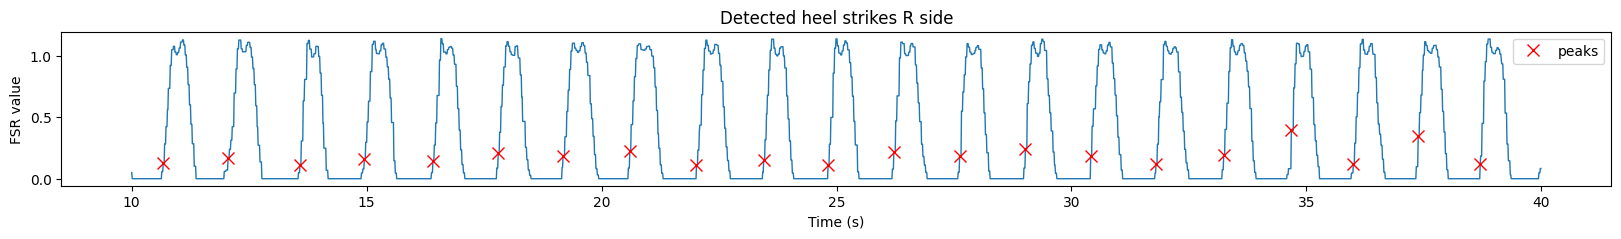

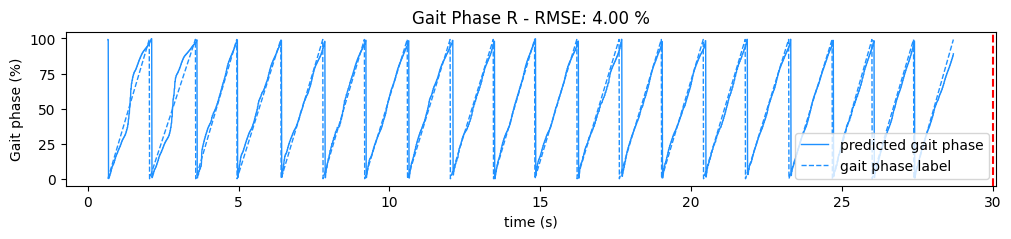

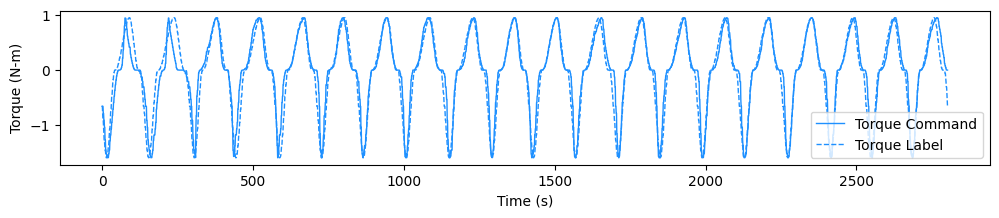

bin_video: 0 past pts (background) + 7 current pts | real_dur=25.1s | video=25.1s @ 10fps (253 frames)
Saved to video-1_1-pc_buffer-grid_key_bin.mp4
Processing Course 2_1 - Incline: LG_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 27, Right: 27
Detected heel strikes at times: [10.63000059 11.7300005  12.86000061 14.00000048 15.07000089 16.18000054
 17.18000078 18.2300005  19.32000065 20.39000082 21.69000053 22.90000057
 24.00000024 25.16000056 26.22000051 27.29000092 28.3100009  29.45000052
 30.50000048 31.59000063 32.67000055 33.74000049 34.80000067 35.90000033
 36.9800005  38.13000059 39.26000094]


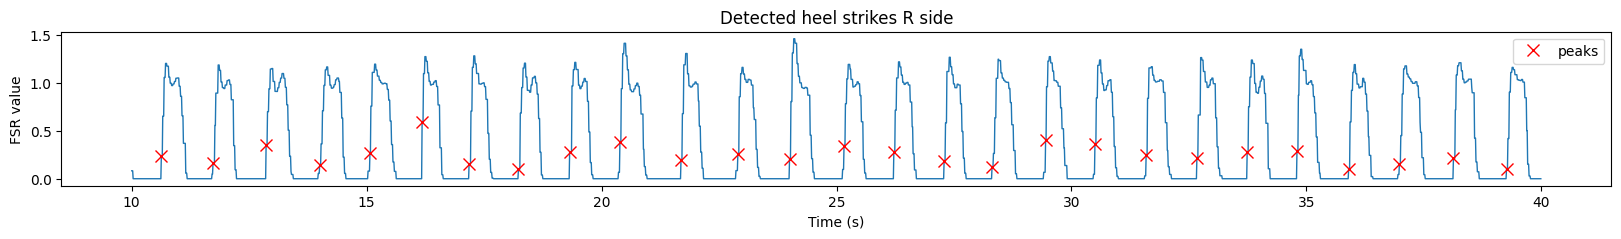

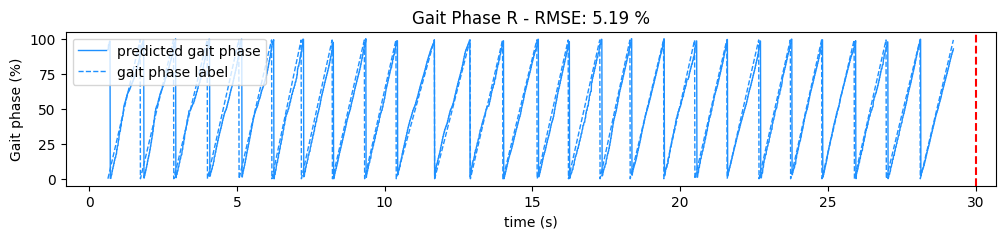

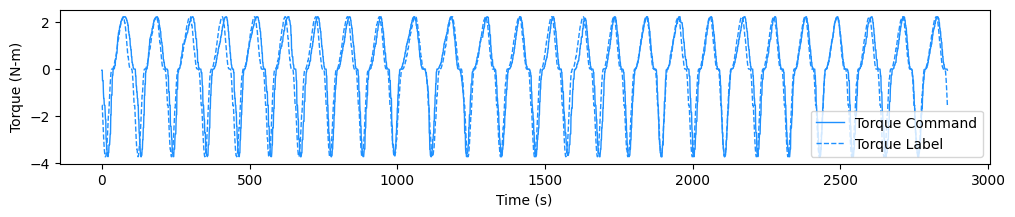

bin_video: 7 past pts (background) + 9 current pts | real_dur=26.4s | video=26.4s @ 10fps (266 frames)
Saved to video-2_1-pc_buffer-grid_key_bin.mp4
Processing Course 3_1 - Incline: RA_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 21, Right: 21
Detected heel strikes at times: [10.8100009  12.1900003  13.60000038 15.05000043 16.45000052 17.83000064
 19.11000085 20.50000072 21.88000059 23.25000048 24.68000054 26.13000083
 27.6200006  29.00000072 30.42000055 31.80000067 33.09000063 34.49000072
 35.92000055 37.35000086 38.75000048]


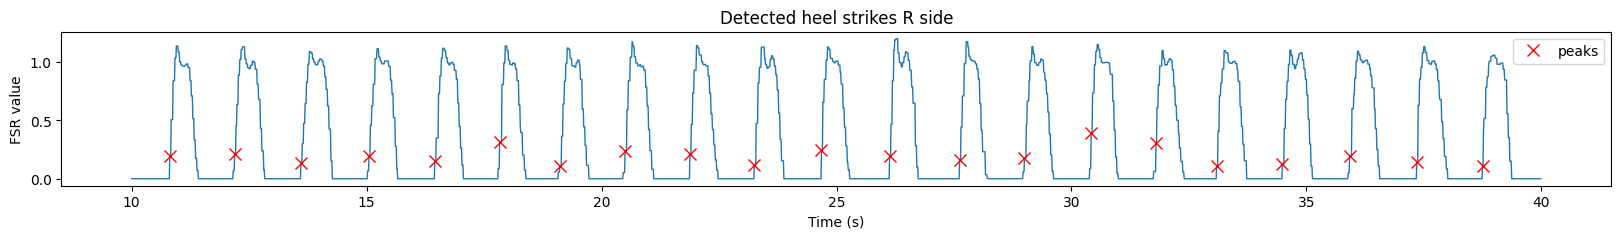

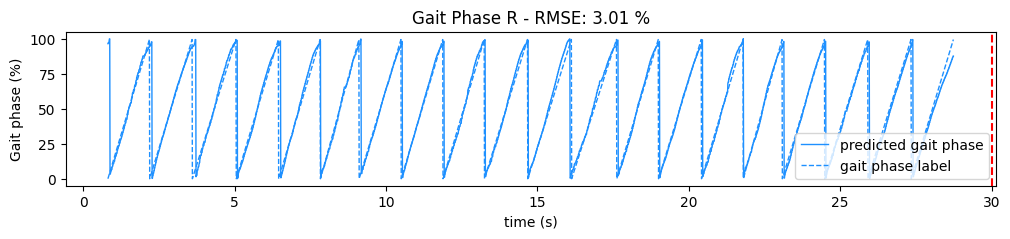

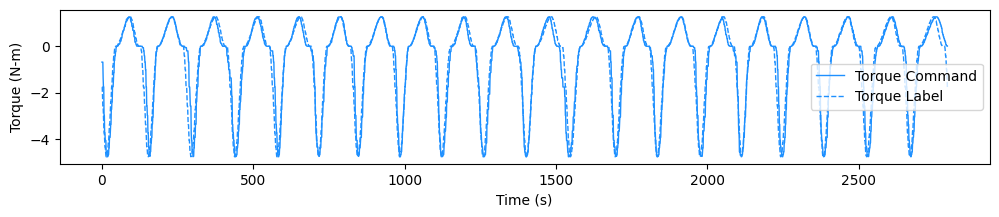

bin_video: 16 past pts (background) + 7 current pts | real_dur=25.1s | video=25.1s @ 10fps (253 frames)
Saved to video-3_1-pc_buffer-grid_key_bin.mp4
Processing Course 4_1 - Incline: RA_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 27, Right: 27
Detected heel strikes at times: [10.64000082 11.78000093 12.89000082 13.99000049 15.13000083 16.26000094
 17.31000066 18.39000034 19.50000048 20.5600009  21.6900003  22.86000061
 23.96002984 25.10000062 26.20000029 27.3300004  28.42000031 29.54000092
 30.60000062 31.71000028 32.80000091 33.8300004  34.93000078 35.97000027
 37.06000066 38.13000083 39.25000048]


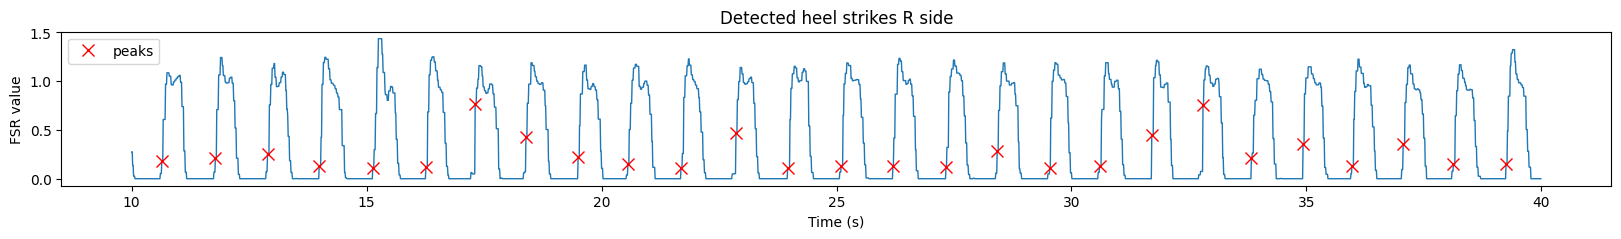

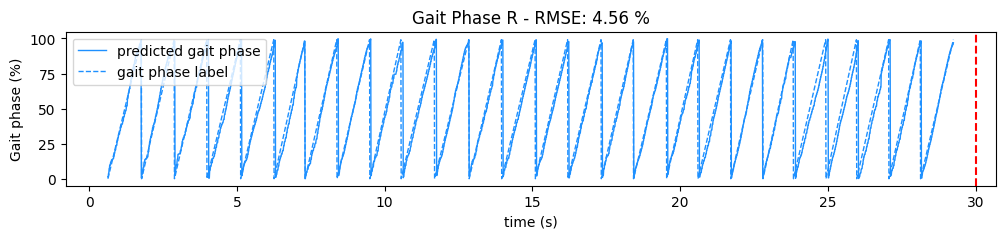

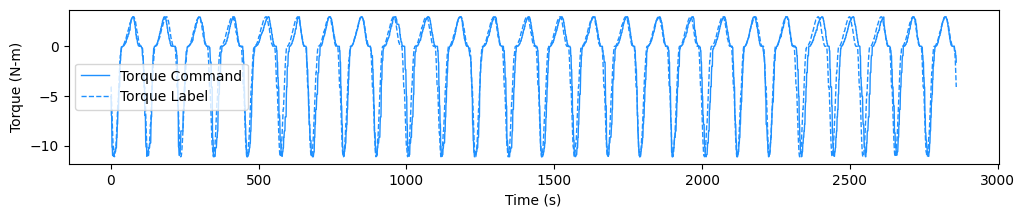

bin_video: 23 past pts (background) + 9 current pts | real_dur=26.4s | video=26.4s @ 10fps (265 frames)
Saved to video-4_1-pc_buffer-grid_key_bin.mp4
Processing Course 5_1 - Incline: RD_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 21, Right: 24
Detected heel strikes at times: [10.15000057 10.81000066 11.46000051 12.26000094 13.65000057 14.93000054
 15.6200006  16.37000036 17.7700007  19.14000082 20.58000064 21.94000053
 23.35000038 24.81000066 26.18000054 27.55000067 28.93000054 30.32000065
 31.6900003  33.17000079 34.56000066 35.89000058 37.38000083 38.82000065]


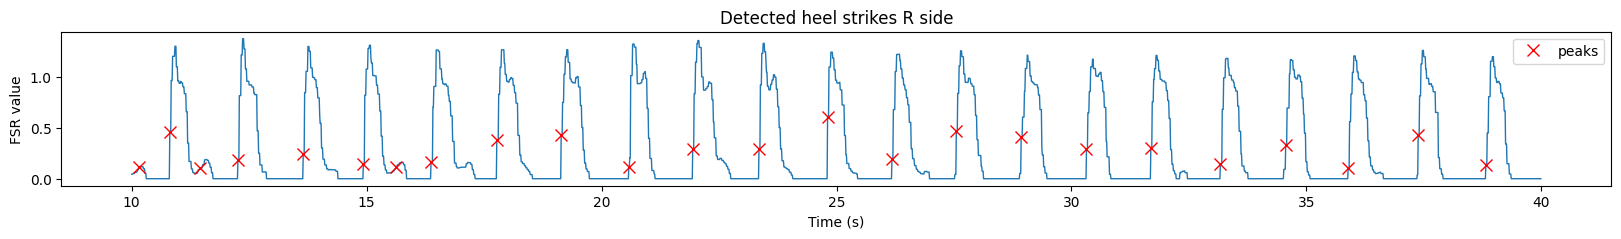

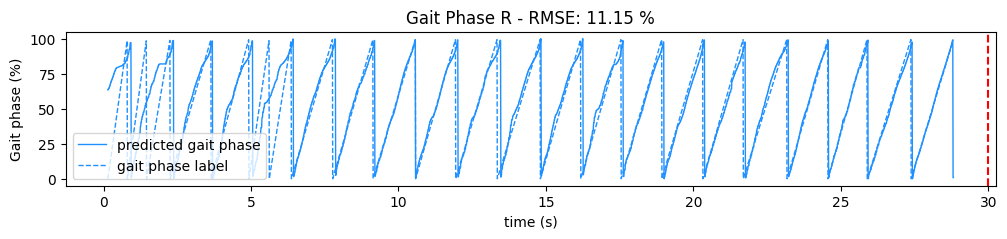

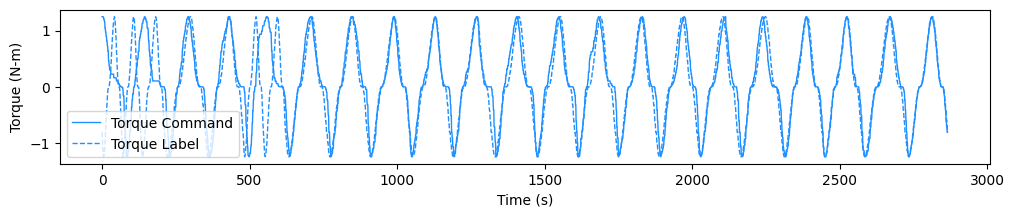

bin_video: 32 past pts (background) + 8 current pts | real_dur=27.4s | video=27.4s @ 10fps (275 frames)
Saved to video-5_1-pc_buffer-grid_key_bin.mp4
Processing Course 6_1 - Incline: RD_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 27, Right: 27
Detected heel strikes at times: [10.6600008  11.72000027 12.85000038 14.03000093 15.20000029 16.25000048
 17.32000065 18.42000055 19.56000066 20.59000063 21.70000052 22.79000115
 23.84000063 24.9800005  26.03000093 27.17000031 28.30000043 29.43000031
 30.52000093 31.6200006  32.74000049 33.8100009  34.90000081 36.05000091
 37.17000055 38.26000071 39.32000065]


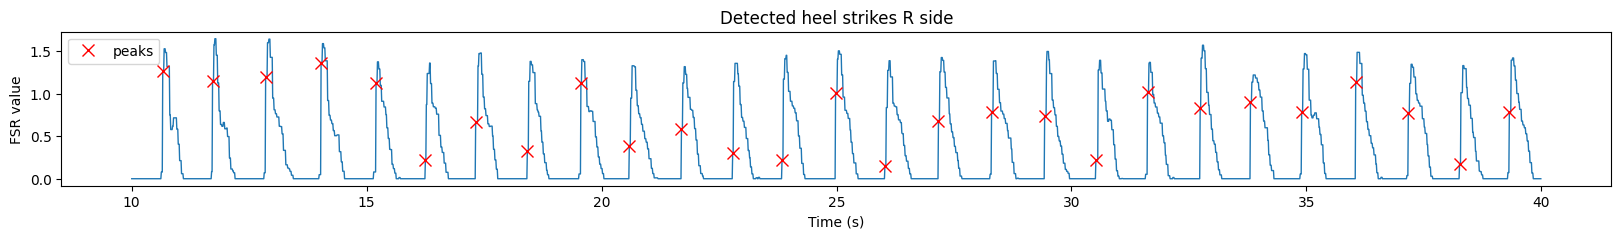

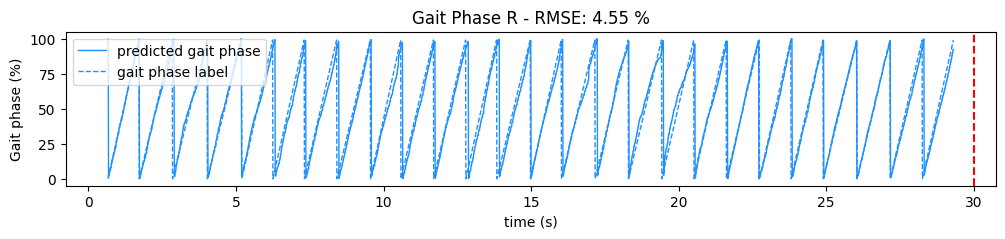

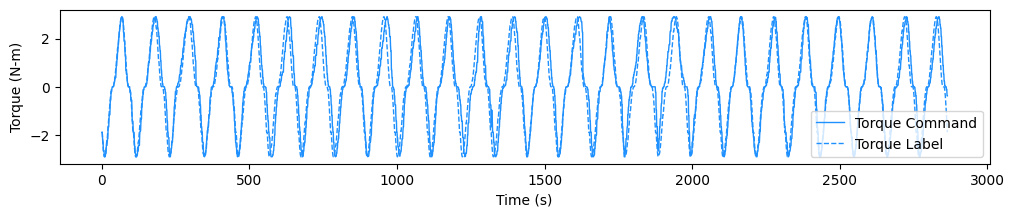

bin_video: 40 past pts (background) + 8 current pts | real_dur=23.2s | video=23.2s @ 10fps (234 frames)
Saved to video-6_1-pc_buffer-grid_key_bin.mp4
Processing Course 7_1 - Incline: LG_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 214, Right: 215
Detected heel strikes at times: [ 10.74000049  12.17000055  13.59000063  14.98000026  16.34000063
  17.78000069  19.15000105  20.54000044  21.98000097  23.38000059
  24.79000044  26.14000058  27.57000065  28.95000052  30.39000058
  31.87000108  33.1900003   34.57000065  35.92000079  37.36000037
  38.70000052  40.12000036  41.56000066  42.94000053  44.37000084
  45.79000068  47.18000031  48.57000065  49.95000052  51.37000036
  52.76000071  54.15000081  55.53000069  56.9800005   58.32000065
  59.7700007   61.19000053  62.53000069  63.92000031  65.30000067
  66.74000049  68.16000056  69.57000041  70.93000054  72.37000036
  73.88000083  75.20000052  76.63000035  78.04000068  79.4100008
  80.800

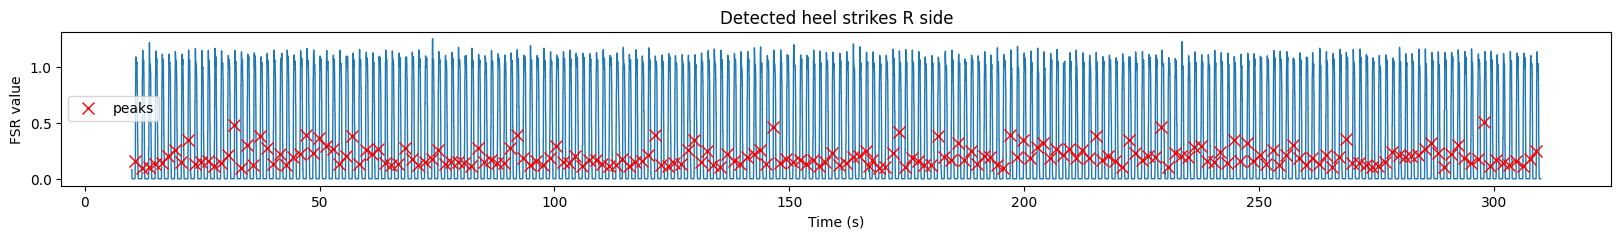

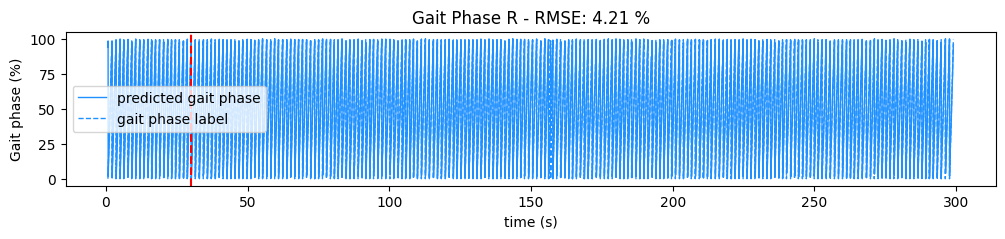

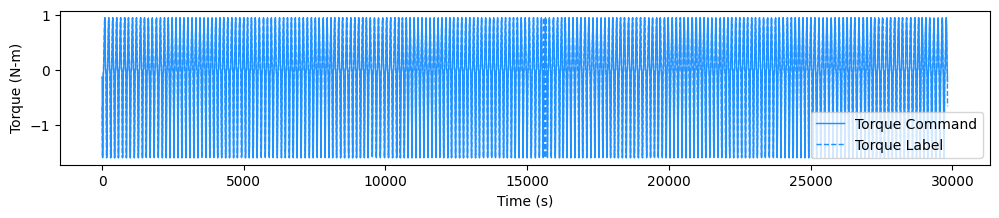

bin_video: 48 past pts (background) + 71 current pts | real_dur=292.6s | video=292.6s @ 10fps (2927 frames)
Saved to video-7_1-pc_buffer-grid_key_bin.mp4
Processing Course 8_1 - Incline: LG_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 10, Right: 9
Detected heel strikes at times: [10.74000072 11.83000088 12.88000059 13.98000073 15.09000087 16.16000032
 17.33000088 18.43000054 19.57000041]


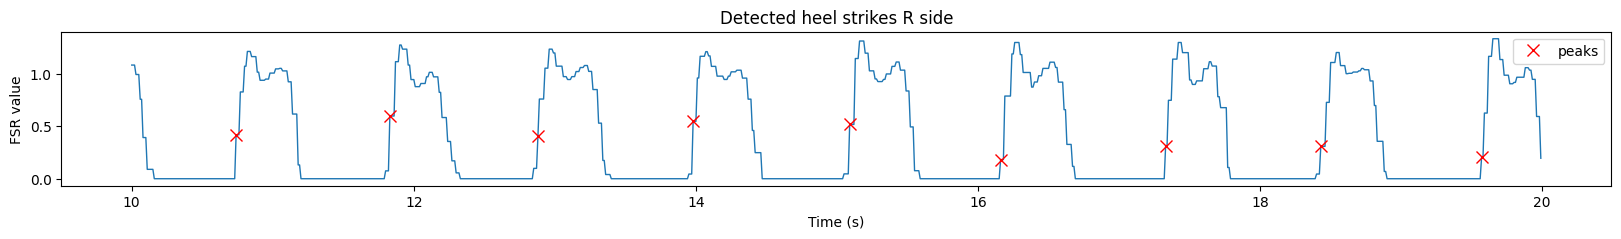

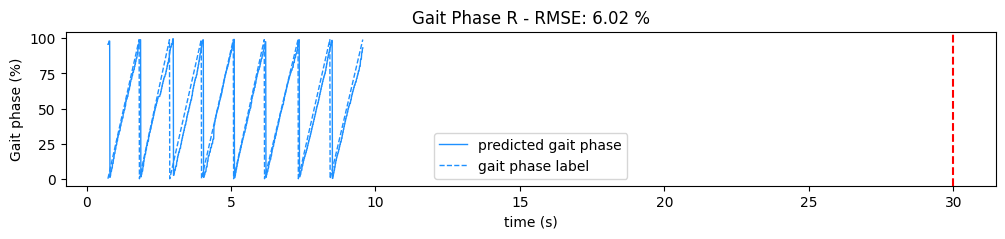

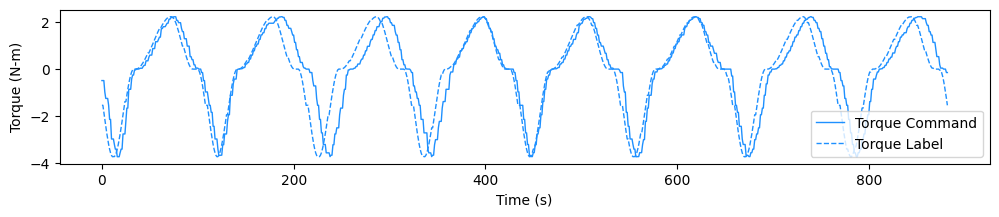

bin_video: 119 past pts (background) + 3 current pts | real_dur=6.7s | video=6.7s @ 10fps (68 frames)
Saved to video-8_1-pc_buffer-grid_key_bin.mp4
Processing Course 8_2 - Incline: RA_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 7, Right: 7
Detected heel strikes at times: [10.74000049 12.14000082 13.51000094 14.96000028 16.39000058 17.76000071
 19.07000065]


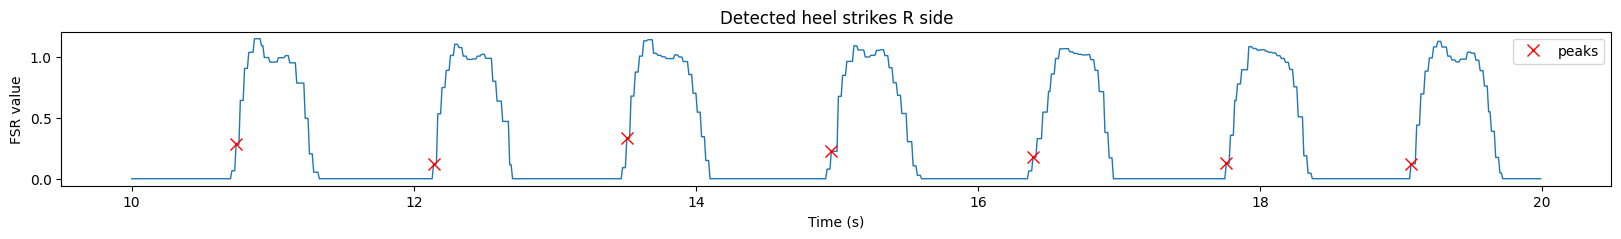

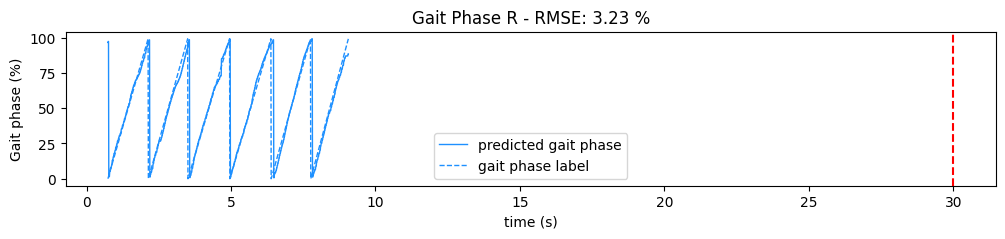

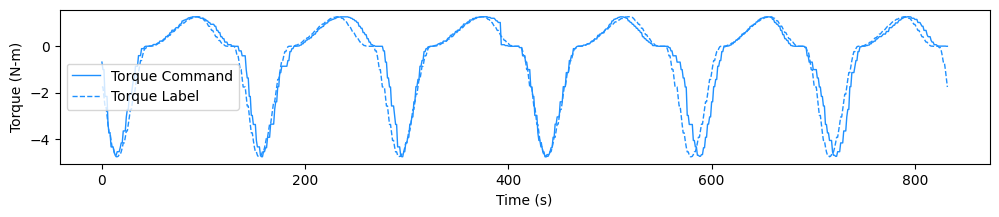

bin_video: 122 past pts (background) + 2 current pts | real_dur=4.2s | video=4.2s @ 10fps (44 frames)
Saved to video-8_2-pc_buffer-grid_key_bin.mp4
Processing Course 8_3 - Incline: RA_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 9, Right: 9
Detected heel strikes at times: [10.73000073 11.81000066 12.84000063 13.93000078 15.12000036 16.2300005
 17.38000059 18.40000057 19.55000091]


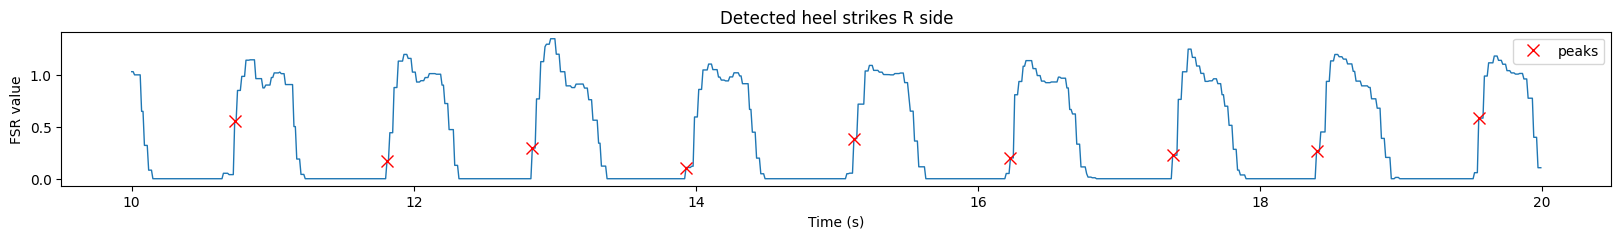

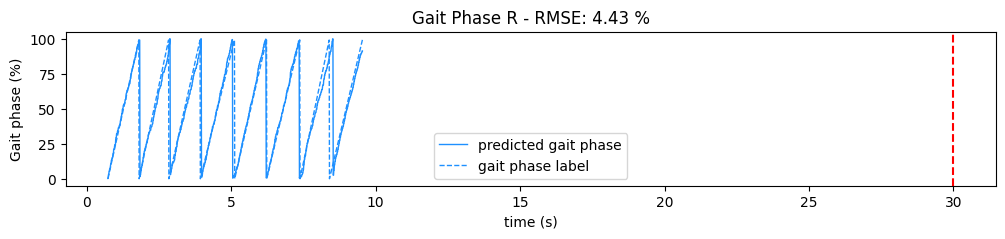

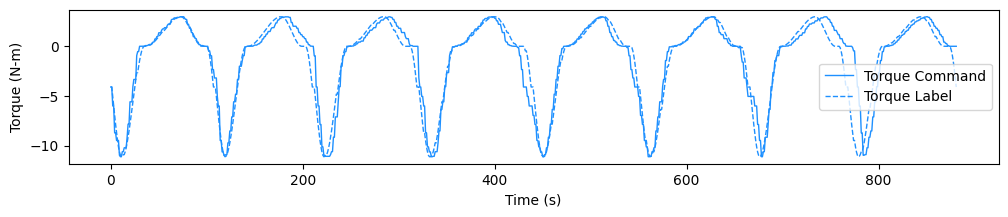

bin_video: 124 past pts (background) + 3 current pts | real_dur=6.7s | video=6.7s @ 10fps (69 frames)
Saved to video-8_3-pc_buffer-grid_key_bin.mp4
Processing Course 8_4 - Incline: RD_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 7, Right: 7
Detected heel strikes at times: [10.79000044 12.21000051 13.58000064 14.93000078 16.4100008  17.7300005
 19.19000053]


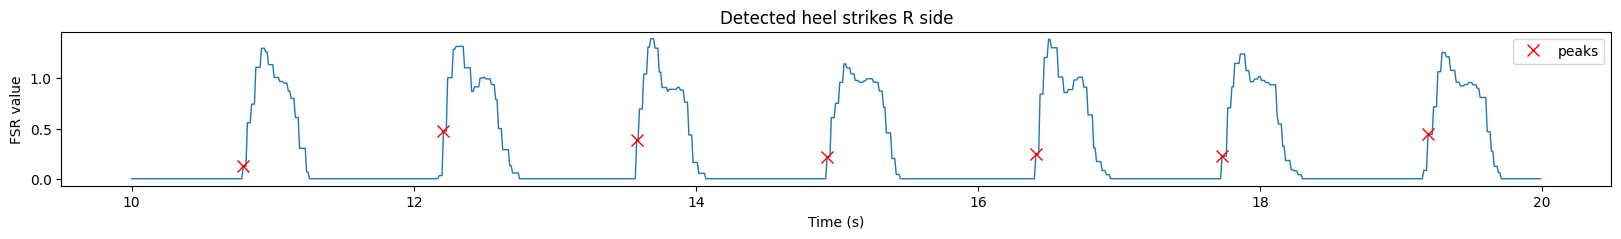

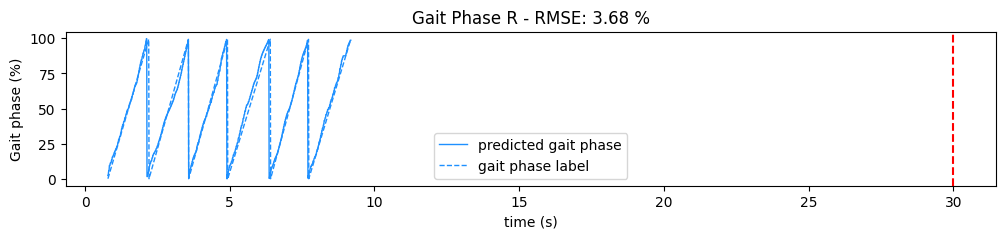

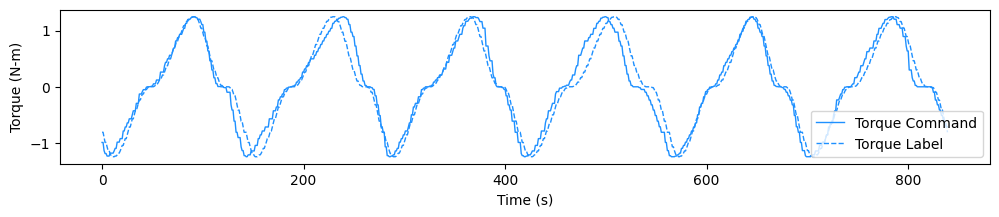

bin_video: 127 past pts (background) + 2 current pts | real_dur=4.2s | video=4.2s @ 10fps (43 frames)
Saved to video-8_4-pc_buffer-grid_key_bin.mp4
Processing Course 8_5 - Incline: RD_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 9, Right: 9
Detected heel strikes at times: [10.62000084 11.75000048 12.9100008  14.03000069 15.11000061 16.22000051
 17.32000065 18.43000078 19.51000071]


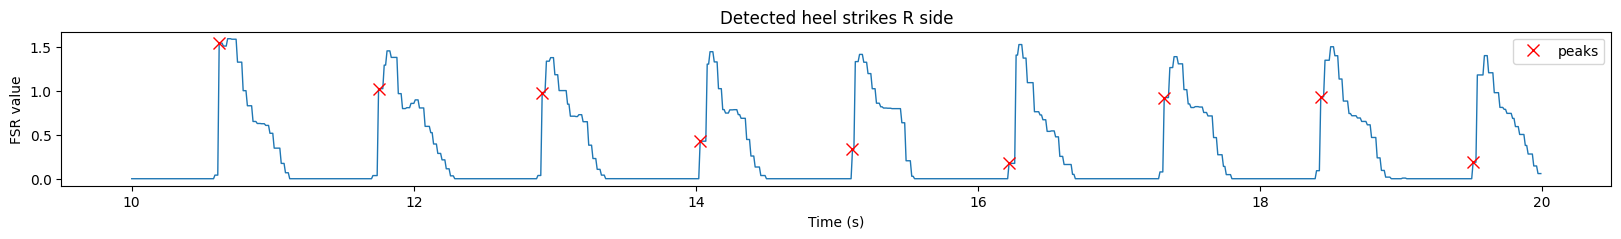

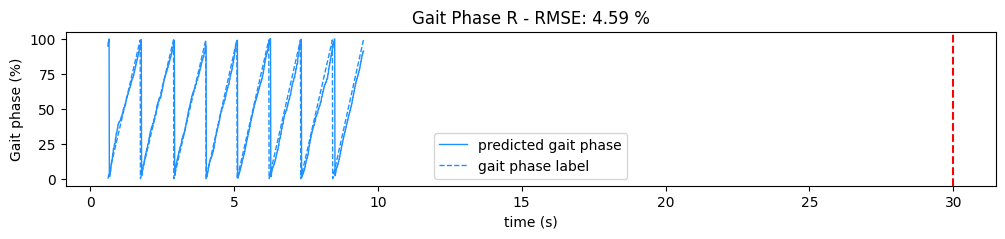

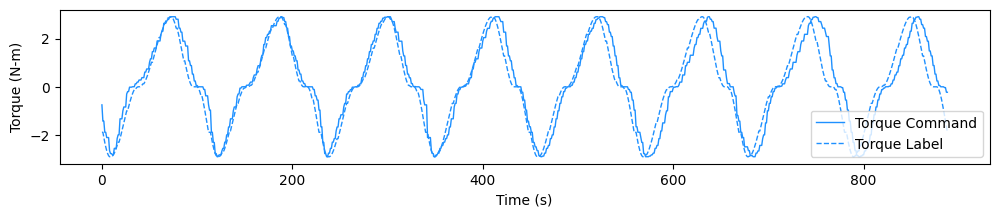

bin_video: 129 past pts (background) + 3 current pts | real_dur=6.6s | video=6.6s @ 10fps (68 frames)
Saved to video-8_5-pc_buffer-grid_key_bin.mp4
Processing Course 7_2 - Incline: LG_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 272, Right: 273
Processing Course 8_6 - Incline: LG_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 7, Right: 7
Processing Course 8_7 - Incline: RA_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 7, Right: 7
Processing Course 8_8 - Incline: RA_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 10, Right: 9
Processing Course 8_9 - Incline: RD_slow
Using GRF threshold of 0.1 for heel strike detection.
Number of detected heel strikes - Left: 7, Right: 7
Processing Course 8_10 - Incline: RD_fast
Using GRF threshold of 0.1 for heel strike detection.
Number of detect

In [205]:
scale_factor = 0.3; torque_limit = 12.5
course_num = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1', '7_1', '8_1', '8_2', '8_3', '8_4', '8_5', '7_2', '8_6', '8_7', '8_8', '8_9', '8_10']
# course_num_eval = ['8_1', '8_2', '8_3', '8_4', '8_5',]# '8_6', '8_7', '8_8', '8_9', '8_10']
course_num_eval = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1', '7_1', '8_1', '8_2', '8_3', '8_4', '8_5']# '7_2', '8_6', '8_7', '8_8', '8_9', '8_10']
incline = ['LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast', 'LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast', 'LG_fast', 'LG_slow', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast']
eval_len = 10
course_len = [eval_len] * len(course_num); data_idx = [[0, eval_len*100] for _ in course_num]
course_len[:6] = [30]*6; course_len[6] = 300; course_len[12] = 300; 
data_idx[:6] = [[0, 30*100]]*6; data_idx[6] = [0, 300*100]; data_idx[12] = [0, 300*100]
start_sec = 10

start_idx_per_course_L, start_idx_per_course_R = [], []

subjects = ['SK_David']
conditions = ['pc_buffer']

# list to store RMSE values for each subject and condition
gc_rmse_L, gc_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
torque_rmse_L, torque_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
hs_indices = {condition: {subject: [] for subject in subjects} for condition in conditions}
course_rmse_L, course_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_rmse_torque_L, course_rmse_torque_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_work_L, course_work_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_pos_work_L, course_pos_work_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}

input_reduced_L, input_reduced_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_key_L, grid_key_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_task_label_L, grid_task_label_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_course_label_L, grid_course_label_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
inc_idx_L, inc_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
spd_idx_L, spd_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
start_idx_L, start_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
update_latency_L, update_latency_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}

input_reduced_PC_L, input_reduced_PC_R = {condition: {subject: {inc: [] for inc in incline} for subject in subjects} for condition in conditions}, {condition: {subject: {inc: [] for inc in incline} for subject in subjects} for condition in conditions}

for subject in subjects:
    subject_kg = weight_kg[subject]
    for condition in conditions:
        for course, inc in zip(course_num, incline):
            course_idx = int(course.split('_')[0]) - 1
            print(f'Processing Course {course} - Incline: {inc}')
            root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
            mtr_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_motor.csv', trigger_indices=data_idx[course_idx])
            imu_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_imu.csv', trigger_indices=data_idx[course_idx])
            output_data = load_jetson_output_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-output_torque.csv', trigger_indices=data_idx[course_idx])
            PC_L_data = load_PC_buffer_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_L.csv')
            PC_R_data = load_PC_buffer_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_R.csv')

            # Stack start indices for each course, adjusting by course length to get absolute indices in the full dataset
            start_idx_per_course_L = PC_L_data['update_start_idx_L'].tolist(); start_idx_per_course_R = PC_R_data['update_start_idx_R'].tolist()
            start_idx_per_course_L = [idx for idx in start_idx_per_course_L if start_sec*100 < idx < (course_len[course_idx]+start_sec)*100]; start_idx_per_course_R = [idx for idx in start_idx_per_course_R if start_sec*100 < idx < (course_len[course_idx]+start_sec)*100]
            start_idx_L[condition][subject].extend([idx + (sum(course_len[:course_idx])-start_sec)*100 for idx in start_idx_per_course_L]); start_idx_R[condition][subject].extend([idx + (sum(course_len[:course_idx])-start_sec)*100 for idx in start_idx_per_course_R])

            # Stack incline, speed, and PC values corresponding to each start index
            inc_L_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_L], -3]; inc_R_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_R], -3]
            spd_L_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_L], -2]; spd_R_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_R], -2]
            spd_idx_L[condition][subject].extend(spd_L_list); spd_idx_R[condition][subject].extend(spd_R_list); inc_idx_L[condition][subject].extend(inc_L_list); inc_idx_R[condition][subject].extend(inc_R_list)
            len_L = len(spd_L_list); len_R = len(spd_R_list)

            # Stack input_reduced values corresponding to each start index
            indices_ = [i for i, x in enumerate(PC_L_data['update_start_idx_L']) if x in set(start_idx_per_course_L)]
            input_reduced_L[condition][subject].extend([PC_L_data['input_reduced_L'][i] for i in indices_]); grid_key_L[condition][subject].extend([PC_L_data['grid_key_L'][i] for i in indices_])
            input_reduced_PC_L[condition][subject][inc].extend([PC_L_data['input_reduced_L'][i] for i in indices_]); update_latency_L[condition][subject].extend([PC_L_data['update_latency_L'][i] for i in indices_])
            grid_task_label_L[condition][subject].extend([inc] * len(indices_)); grid_course_label_L[condition][subject].extend([course] * len(indices_))
            
            indices_ = [i for i, x in enumerate(PC_R_data['update_start_idx_R']) if x in set(start_idx_per_course_R)]
            input_reduced_R[condition][subject].extend([PC_R_data['input_reduced_R'][i] for i in indices_]); grid_key_R[condition][subject].extend([PC_R_data['grid_key_R'][i] for i in indices_])
            grid_task_label_R[condition][subject].extend([inc] * len(indices_)); grid_course_label_R[condition][subject].extend([course] * len(indices_))            
            input_reduced_PC_R[condition][subject][inc].extend([PC_R_data['input_reduced_R'][i] for i in indices_]); update_latency_R[condition][subject].extend([PC_R_data['update_latency_R'][i] for i in indices_])

            # Detect heel strikes
            grf_threshold = 0.15 if subject == 'SK_Rajiv' else 0.10
            print(f"Using GRF threshold of {grf_threshold} for heel strike detection.")
            hs_indices_L = detect_heel_strike(mtr_data[:, 5], threshold=grf_threshold, min_interval=50, max_interval=210, side='L')
            hs_indices_R = detect_heel_strike(mtr_data[:, 6], threshold=grf_threshold, min_interval=50, max_interval=210, side='R')
            print(f'Number of detected heel strikes - Left: {len(hs_indices_L)}, Right: {len(hs_indices_R)}')
            # print(hs_indices_L, hs_indices_R)

            # Use from first to last heel strikes for analysis to ensure full gait cycles
            gait_phase_label_L = polar_to_percentage(gait_cycle_generator(hs_indices_L))
            gait_phase_label_R = polar_to_percentage(gait_cycle_generator(hs_indices_R))
            predictions_R = output_data[hs_indices_R[0]:hs_indices_R[-1], 2]
            predictions_L = output_data[hs_indices_L[0]:hs_indices_L[-1], 1]

            torque_cmd_R = output_data[hs_indices_R[0]:hs_indices_R[-1], 4]
            torque_cmd_L = output_data[hs_indices_L[0]:hs_indices_L[-1], 3]

            # Get gt and predicted torque values using the spline functions for each incline and speed
            speeds_L = output_data[hs_indices_L[0]:hs_indices_L[-1], -2]; speeds_R = output_data[hs_indices_R[0]:hs_indices_R[-1], -2]
            torque_label_L = np.array([torque_splines[incline_values[inc]][s][int(gp)] 
                        for s, gp in zip(speeds_L, gait_phase_label_L)]) * subject_kg * scale_factor
            torque_label_L = np.clip(torque_label_L, -torque_limit, torque_limit)  # Clip to torque limits
            torque_label_R = np.array([torque_splines[incline_values[inc]][s][int(gp)] 
                        for s, gp in zip(speeds_R, gait_phase_label_R)]) * subject_kg * scale_factor

            torque_label_R = np.clip(torque_label_R, -torque_limit, torque_limit)  # Clip to torque limits
            torque_pred_L = np.array([torque_splines[incline_values[inc]][s][int(p)] 
                        for s, p in zip(speeds_L, predictions_L)]) * subject_kg * scale_factor
            torque_pred_R = np.array([torque_splines[incline_values[inc]][s][int(p)] 
                        for s, p in zip(speeds_R, predictions_R)]) * subject_kg * scale_factor

            rmse_L, _course_rmse_L, _course_rmse_torque_L, _gc_rmse_L, _torque_rmse_L, error_list_L = get_prediction_accuracy(predictions_L, gait_phase_label_L, torque_cmd_L, torque_label_L, hs_indices_L, segments_course, leave_out_gc=[], course_name=course_idx + 1, course_dur=None)
            rmse_R, _course_rmse_R, _course_rmse_torque_R, _gc_rmse_R, _torque_rmse_R, error_list_R = get_prediction_accuracy(predictions_R, gait_phase_label_R, torque_cmd_R, torque_label_R, hs_indices_R, segments_course, leave_out_gc=[], course_name=course_idx + 1, course_dur=None)
            
            course_rmse_L[condition][subject].extend(_course_rmse_L);   course_rmse_R[condition][subject].extend(_course_rmse_R);   course_rmse_torque_L[condition][subject].extend(_course_rmse_torque_L);   course_rmse_torque_R[condition][subject].extend(_course_rmse_torque_R)
            gc_rmse_L[condition][subject].append(_gc_rmse_L); gc_rmse_R[condition][subject].append(_gc_rmse_R); hs_indices[condition][subject].append(hs_indices_L)
            torque_rmse_L[condition][subject].append(_torque_rmse_L); torque_rmse_R[condition][subject].append(_torque_rmse_R)

            if course in course_num_eval:
                # plot_hs_detection(mtr_data, imu_data, hs_indices_L, side='L', xlim=None)
                plot_hs_detection(mtr_data, imu_data, hs_indices_R, side='R', xlim=None)
                # plot_gait_phase_prediction(output_data, gait_phase_label_L, rmse_L, error_list_L, _course_rmse_L, hs_indices_L, segments_course, start_sec, side='L', leave_out_gc=[], xlim=None)
                plot_gait_phase_prediction(output_data, gait_phase_label_R, rmse_R, error_list_R, _course_rmse_R, hs_indices_R, segments_course, start_sec, side='R', leave_out_gc=[], xlim=None, condition=condition)
                # plot_torque(torque_cmd_L, torque_label_L, side='L')
                plot_torque(torque_cmd_R, torque_label_R, side='R', condition=condition)
                
                # t = output_data[hs_indices_R[0]:hs_indices_R[-1], 0] - start_sec
                # gait_phase_video(output_data, gait_phase_label_R, hs_indices_R, start_sec, side='R', condition=condition, fps=10, save_path=f'video-{course}-{condition}-gait_phase.mp4')
                # torque_video(torque_cmd_R, torque_label_R, t, side='R', condition=condition, fps=10, save_path=f'video-{course}-{condition}-torque.mp4')

                if condition == 'pc_buffer':
                    # bin_video(start_idx_R[condition][subject], input_reduced_R[condition][subject], grid_task_label_R[condition][subject],
                    #           course_labels=grid_course_label_R[condition][subject], current_course=course,
                    #           side='R', fps=10, save_path=f'video-{course}-{condition}-gait_phase_bin.mp4',
                    #           xlim=[-13, -5], ylim=[2, 11], zlim=[60, 150])
                    grid_key_video(start_idx_R[condition][subject], grid_key_R[condition][subject], grid_task_label_R[condition][subject],
                                   course_labels=grid_course_label_R[condition][subject], current_course=course,
                                   side='R', fps=10, save_path=f'video-{course}-{condition}-grid_key_bin.mp4')

            # work, positive_work = plot_positive_power(imu_data[hs_indices_L[0]:hs_indices_L[-1], 5], torque_cmd_L)
            # course_work_L.append(work); course_pos_work_L.append(positive_work)
            # work, positive_work = plot_positive_power(imu_data[hs_indices_R[0]:hs_indices_R[-1], 11], torque_cmd_R)
            # course_work_R.append(work); course_pos_work_R.append(positive_work)

            # plot_imu_saggital(imu_data)
            # plot_jerk(imu_data)

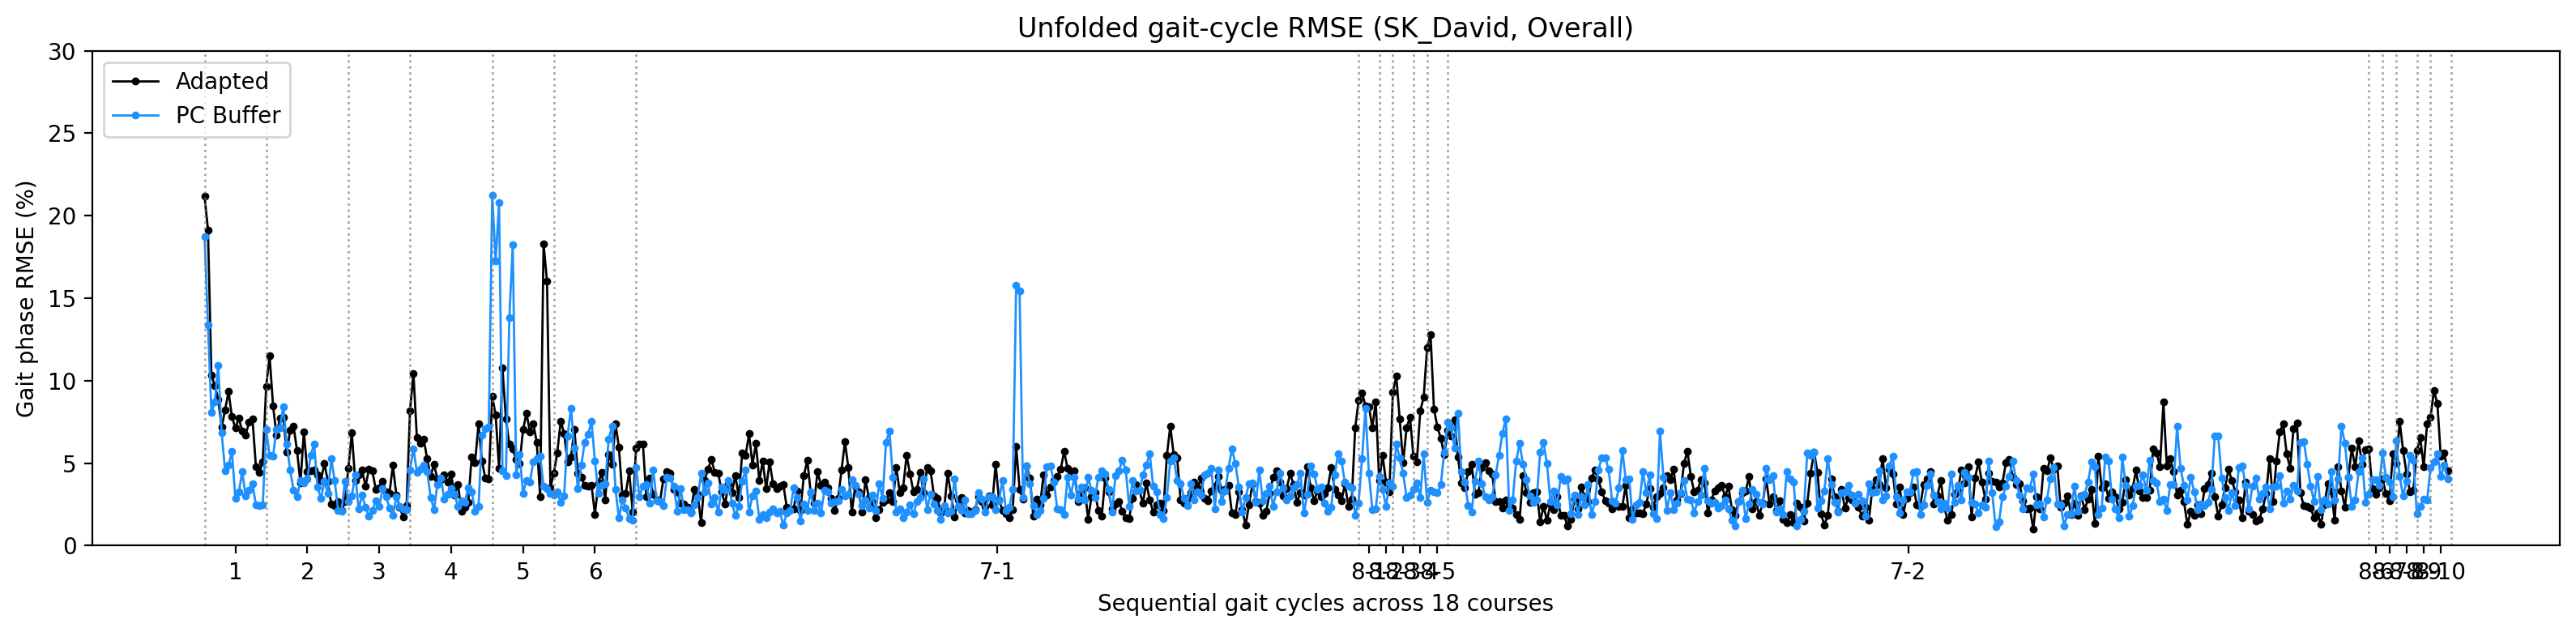

In [11]:
subject = 'SK_David'

plot_gc_rmses(
    segments_condition[1:],
    gc_rmse_R['adapted'][subject], gc_rmse_L['adapted'][subject],
    gc_rmse_R['pc_buffer'][subject], gc_rmse_L['pc_buffer'][subject],
    side='Overall'
)

Adapted RMSE avg across all tasks: 6.38 %
PC Buffer RMSE avg across all tasks: 5.46 %


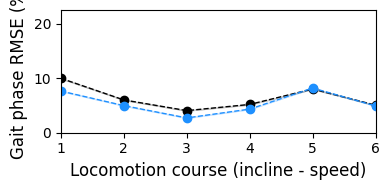

Subjects where adapted RMSE < pc_buffer RMSE (averaged across all courses and sides):

Condition: LG_Diff

Condition: RA_Same
SK_David: adapted=1.1, pc_buffer=1.2, difference=-0.098

Condition: RA_Diff

Condition: RD_Same

Condition: RD_Diff


/home/metamobility5/miniconda3/envs/cs_tcn/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


ValueError: array must not contain infs or NaNs

In [13]:
# adapted_rmse = np.mean([course_rmse_L['adapted'], course_rmse_R['adapted']], axis=0).tolist(); adapted_rmse_torque = np.mean([course_rmse_torque_L['adapted'], course_rmse_torque_R['adapted']], axis=0).tolist()
# pc_buffer_rmse = np.mean([course_rmse_L['pc_buffer'], course_rmse_R['pc_buffer']], axis=0).tolist(); pc_buffer_rmse_torque = np.mean([course_rmse_torque_L['pc_buffer'], course_rmse_torque_R['pc_buffer']], axis=0).tolist()

plot_course_rmses(segments_condition[1:], subjects, course_rmse_R['adapted'], course_rmse_L['adapted'], course_rmse_R['pc_buffer'], course_rmse_L['pc_buffer'],
                    course_rmse_torque_R['adapted'], course_rmse_torque_L['adapted'], course_rmse_torque_R['pc_buffer'], course_rmse_torque_L['pc_buffer'])

plot_course_rmses_2(subjects, course_rmse_R['adapted'],	course_rmse_L['adapted'], course_rmse_R['pc_buffer'], course_rmse_L['pc_buffer'], data='gc')

plot_course_rmses_2(subjects, course_rmse_torque_R['adapted'],	course_rmse_torque_L['adapted'], course_rmse_torque_R['pc_buffer'], course_rmse_torque_L['pc_buffer'], data='torque')


Condition: LG - Different Speed
      H SK_David R 7 score=8.804 6 6
      M SK_David L 7 score=8.139 6 7
      L SK_David L 13 score=2.819 4 4

Condition: LG to RA - Same Speed
      H SK_David R 8 score=5.336 4 4
      M SK_David L 15 score=5.110 6 7
      L SK_David L 8 score=2.944 4 4

Condition: LG to RA - Different Speed
      H SK_David R 9 score=8.113 6 6
      M SK_David L 9 score=7.630 6 6
      L SK_David R 14 score=3.657 4 4

Condition: LG to RD - Same Speed
      H SK_David R 10 score=8.179 4 4
      M SK_David L 17 score=7.920 6 6
      L SK_David L 10 score=5.665 4 4

Condition: LG to RD - Different Speed
      H SK_David R 11 score=8.770 6 6
      M SK_David L 11 score=8.661 6 6
      L SK_David R 16 score=5.296 4 4


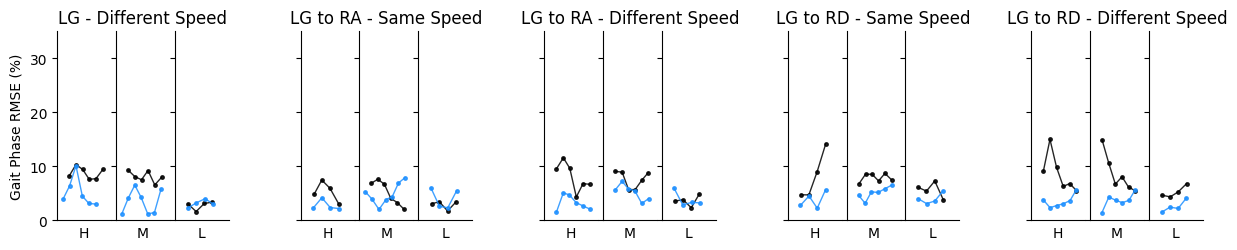


Condition: LG - Different Speed
      H SK_David R 7 score=1.184 6 6
      M SK_David L 7 score=0.855 6 7
      L SK_David L 13 score=0.165 4 4

Condition: LG to RA - Same Speed
      H SK_David L 15 score=1.883 6 7
      M SK_David R 15 score=1.704 6 6
      L SK_David L 8 score=0.376 4 4

Condition: LG to RA - Different Speed
      H SK_David R 9 score=3.132 6 6
      M SK_David L 9 score=1.436 6 6
      L SK_David L 14 score=0.468 4 4

Condition: LG to RD - Same Speed
      H SK_David R 17 score=1.003 6 6
      M SK_David L 17 score=0.920 6 6
      L SK_David L 10 score=0.309 4 4

Condition: LG to RD - Different Speed
      H SK_David R 11 score=1.255 6 6
      M SK_David L 11 score=1.251 6 6
      L SK_David R 16 score=0.248 4 4


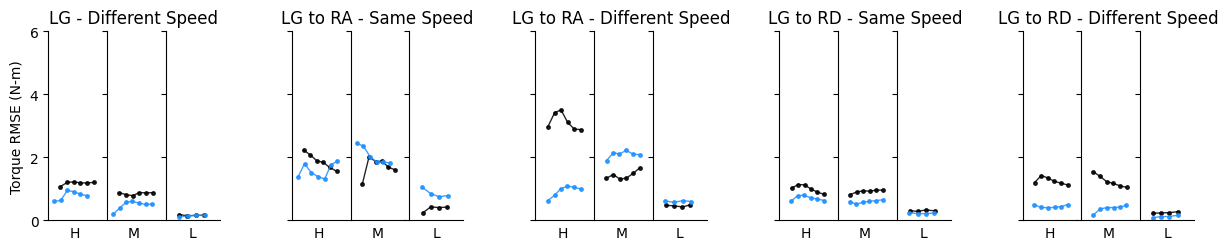

In [14]:
process_representative_rmse(subjects, gc_rmse_R, gc_rmse_L, hs_indices, data='gc')
process_representative_rmse(subjects, torque_rmse_R, torque_rmse_L, hs_indices, data='torque')

[SK_David] Aggregated total rows * 4: 576
[SK_David] Total replayed task labels counted: 575


,task_label,x,y,percentage_avg,percentage_std
0,"[-10.0, 0.3]",-10.0,0.3,5.0,0.0
1,"[0.0, 0.3]",0.0,0.3,21.0,0.0
2,"[10.0, 0.3]",10.0,0.3,2.6,0.0
3,"[-10.0, 0.7]",-10.0,0.7,30.3,0.0
4,"[0.0, 0.7]",0.0,0.7,2.4,0.0
5,"[10.0, 0.7]",10.0,0.7,38.6,0.0


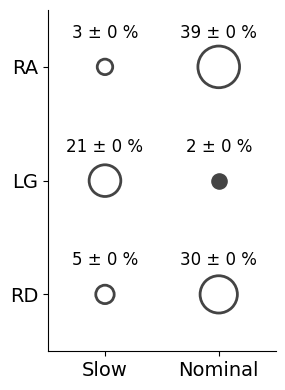

In [12]:
import ast
from collections import Counter

course_specs = [
    ('7_1', 'LG_slow'),
    # ('7_2', 'LG_fast'),
]
condition = 'pc_buffer'

side_to_target = {
    'L': 'replayed_bins_task_label_L',
    'R': 'replayed_bins_task_label_R',
}

def parse_task_labels(value):
    if pd.isna(value):
        return []

    if isinstance(value, (np.ndarray, pd.Series)):
        arr = np.asarray(value, dtype=float)
        if arr.size == 0:
            return []
        arr = arr.reshape(-1, 2)
        return [tuple(np.round(row, 3)) for row in arr]

    if isinstance(value, str):
        text = value.strip()
        if text in ('', '[]'):
            return []

        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (list, tuple, np.ndarray, pd.Series)):
                arr = np.asarray(parsed, dtype=float)
                if arr.ndim == 1 and arr.size == 2:
                    return [tuple(np.round(arr, 3))]
                if arr.ndim == 2 and arr.shape[1] == 2:
                    return [tuple(np.round(row, 3)) for row in arr]
        except (ValueError, SyntaxError):
            pass

        flat = np.fromstring(
            text.replace('[', ' ').replace(']', ' ').replace('\\n', ' '),
            sep=' '
        )
        if flat.size >= 2 and flat.size % 2 == 0:
            return [tuple(np.round(row, 3)) for row in flat.reshape(-1, 2)]

        return []

    if isinstance(value, (list, tuple)):
        arr = np.asarray(value, dtype=float)
        if arr.ndim == 1 and arr.size == 2:
            return [tuple(np.round(arr, 3))]
        if arr.ndim == 2 and arr.shape[1] == 2:
            return [tuple(np.round(row, 3)) for row in arr]

    return []

# Collect per-subject replay-label counts first.
subject_counters = []
subject_totals = []

for subject in subjects:
    root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
    all_replayed_task_labels = []
    total_slots = 0

    for course, inc in course_specs:
        for side, target_col in side_to_target.items():
            file_path = f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_{side}.csv'
            pc_df = load_PC_buffer_data(file_path)
            total_slots += len(pc_df) * 4

            if target_col not in pc_df.columns:
                raise KeyError(f"Column '{target_col}' not found in {file_path}. Available columns: {pc_df.columns.tolist()}")

            parsed_labels = []
            for value in pc_df[target_col]:
                parsed_labels.extend(parse_task_labels(value))

            all_replayed_task_labels.extend(parsed_labels)

    counter = Counter(all_replayed_task_labels)
    subject_counters.append(counter)
    subject_totals.append(sum(counter.values()))

    print(f"[{subject}] Aggregated total rows * 4: {total_slots}")
    print(f"[{subject}] Total replayed task labels counted: {subject_totals[-1]}")

# Build a canonical label set so every subject uses the same column order.
canonical_labels = sorted(
    set().union(*(set(c.keys()) for c in subject_counters)),
    key=lambda t: (t[1], t[0])
    )

if len(canonical_labels) == 0:
    raise ValueError('No replayed task labels found in the selected files.')

percentages = np.zeros((len(subjects), len(canonical_labels)), dtype=float)
for subj_idx, counter in enumerate(subject_counters):
    total = subject_totals[subj_idx]
    if total == 0:
        continue
    for col_idx, label in enumerate(canonical_labels):
        percentages[subj_idx, col_idx] = counter.get(label, 0) / total * 100

percentage_avg = np.mean(percentages, axis=0)
percentage_std = np.std(percentages, axis=0)

task_label_count_df = pd.DataFrame({
    'task_label_tuple': canonical_labels,
    'percentage_avg': np.round(percentage_avg, 1),
    'percentage_std': np.round(percentage_std, 1),
})
task_label_count_df[['x', 'y']] = pd.DataFrame(
    task_label_count_df['task_label_tuple'].tolist(),
    index=task_label_count_df.index
)
task_label_count_df['task_label'] = task_label_count_df['task_label_tuple'].apply(
    lambda v: f'[{v[0]:.1f}, {v[1]:.1f}]'
 )
display(task_label_count_df[['task_label', 'x', 'y', 'percentage_avg', 'percentage_std']])

# In this dataset: x=incline (3 levels), y=speed (2 levels).
incline_vals = sorted(task_label_count_df['x'].unique().tolist())
speed_vals = sorted(task_label_count_df['y'].unique().tolist())

if len(incline_vals) != 3 or len(speed_vals) != 2:
    raise ValueError(
        f'Expected a 3x2 incline-speed grid but found {len(incline_vals)} inclines and {len(speed_vals)} speeds: '
        f'incline={incline_vals}, speed={speed_vals}'
    )

speed_to_plot = {speed_vals[0]: 1, speed_vals[1]: 2}
speed_to_name = {speed_vals[0]: 'Slow', speed_vals[1]: 'Nominal'}
incline_to_plot = {inc: i for i, inc in enumerate(incline_vals)}
incline_to_name = {incline_vals[0]: 'RD', incline_vals[1]: 'LG', incline_vals[2]: 'RA'}

# Marker area scaling in points^2: proportional to replay percentage.
s_min = 120
s_max = 900
p_min = float(task_label_count_df['percentage_avg'].min())
p_max = float(task_label_count_df['percentage_avg'].max())

def marker_size_from_pct(pct):
    if np.isclose(p_min, p_max):
        return (s_min + s_max) / 2
    return s_min + (pct - p_min) * (s_max - s_min) / (p_max - p_min)

points = []
for _, row in task_label_count_df.iterrows():
    pct = float(row['percentage_avg'])
    points.append(
        (
            speed_to_plot[row['y']],
            incline_to_plot[row['x']],
            f"{row['percentage_avg']:.0f} ± {row['percentage_std']:.0f} %",
            marker_size_from_pct(pct),
            row['x'],
            row['y'],
        )
    )

# Choose the LG-Nominal-like center: middle incline and faster speed.
center_incline = incline_vals[1]
center_speed = speed_vals[1]
center_point = None
peripheral_points = []
for x_plot, y_plot, label, marker_size, raw_incline, raw_speed in points:
    if np.isclose(raw_incline, center_incline) and np.isclose(raw_speed, center_speed):
        center_point = (x_plot, y_plot, label, marker_size)
    else:
        peripheral_points.append((x_plot, y_plot, label, marker_size))

if center_point is None and peripheral_points:
    center_point = peripheral_points.pop(0)

fig, ax = plt.subplots(figsize=(5, 4))

for x, y, label, marker_size in peripheral_points:
    ax.scatter(x, y, s=marker_size, edgecolor='#444444', facecolor='none', linestyle='-', linewidth=2, zorder=3)
    ax.text(x, y + 0.3, label, ha='center', va='center', fontsize=12)

if center_point is not None:
    ax.scatter(center_point[0], center_point[1], s=center_point[3], color='#444444', zorder=3)
    ax.text(center_point[0], center_point[1] + 0.3, center_point[2], ha='center', va='center', fontsize=12)

ax.set_xticks([1, 2])
ax.set_xticklabels([speed_to_name[speed_vals[0]], speed_to_name[speed_vals[1]]], fontsize=14)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([incline_to_name[incline_vals[0]], incline_to_name[incline_vals[1]], incline_to_name[incline_vals[2]]], fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.rcParams['pdf.fonttype'] = 42
plt.savefig('Replayed_percent_slow.pdf', dpi=300)
plt.show()

Aggregated total rows * 4: 576
Total replayed task labels counted: 575


,task_label,x,y,replay_count,percentage
0,"[10.0, 0.7]",10.0,0.7,222,38.6
1,"[-10.0, 0.7]",-10.0,0.7,174,30.3
2,"[0.0, 0.3]",0.0,0.3,121,21.0
3,"[-10.0, 0.3]",-10.0,0.3,29,5.0
4,"[10.0, 0.3]",10.0,0.3,15,2.6
5,"[0.0, 0.7]",0.0,0.7,14,2.4


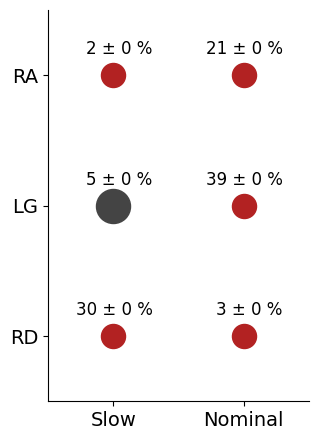

In [13]:
import ast

course_specs = [
	('7_1', 'LG_slow'),
	# ('7_2', 'LG_fast'),
]
condition = 'pc_buffer'
percentages = np.zeros((len(subjects), 6))

for subj_idx, subject in enumerate(subjects):

	root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
	side_to_target = {
		'L': 'replayed_bins_task_label_L',
		'R': 'replayed_bins_task_label_R',
	}


	def parse_task_labels(value):
		if pd.isna(value):
			return []

		if isinstance(value, (np.ndarray, pd.Series)):
			arr = np.asarray(value, dtype=float)
			if arr.size == 0:
				return []
			arr = arr.reshape(-1, 2)
			return [tuple(np.round(row, 3)) for row in arr]

		if isinstance(value, str):
			text = value.strip()
			if text in ('', '[]'):
				return []

			try:
				parsed = ast.literal_eval(text)
				if isinstance(parsed, (list, tuple, np.ndarray, pd.Series)):
					arr = np.asarray(parsed, dtype=float)
					if arr.ndim == 1 and arr.size == 2:
						return [tuple(np.round(arr, 3))]
					if arr.ndim == 2 and arr.shape[1] == 2:
						return [tuple(np.round(row, 3)) for row in arr]
			except (ValueError, SyntaxError):
				pass

			flat = np.fromstring(
				text.replace('[', ' ').replace(']', ' ').replace('\n', ' '),
				sep=' '
			)
			if flat.size >= 2 and flat.size % 2 == 0:
				return [tuple(np.round(row, 3)) for row in flat.reshape(-1, 2)]

			return []

		if isinstance(value, (list, tuple)):
			arr = np.asarray(value, dtype=float)
			if arr.ndim == 1 and arr.size == 2:
				return [tuple(np.round(arr, 3))]
			if arr.ndim == 2 and arr.shape[1] == 2:
				return [tuple(np.round(row, 3)) for row in arr]

		return []

	all_replayed_task_labels = []
	source_summary = []
	total_slots = 0

	for course, inc in course_specs:
		for side, target_col in side_to_target.items():
			file_path = f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_{side}.csv'
			pc_df = load_PC_buffer_data(file_path)

			total_slots += len(pc_df) * 4

			if target_col not in pc_df.columns:
				raise KeyError(f"Column '{target_col}' not found in {file_path}. Available columns: {pc_df.columns.tolist()}")

			parsed_labels = []
			for value in pc_df[target_col]:
				parsed_labels.extend(parse_task_labels(value))

			all_replayed_task_labels.extend(parsed_labels)
			source_summary.append({
				'course': course,
				'incline_speed': inc,
				'side': side,
				'n_rows': len(pc_df),
				'n_replayed_labels': len(parsed_labels),
			})

	task_label_count_df = (
		pd.Series(all_replayed_task_labels, name='task_label')
		.value_counts()
		.rename_axis('task_label')
		.reset_index(name='replay_count')
	)

	if not task_label_count_df.empty:
		task_label_count_df[['x', 'y']] = pd.DataFrame(
			task_label_count_df['task_label'].tolist(),
			index=task_label_count_df.index
		)
		task_label_count_df['task_label'] = task_label_count_df['task_label'].apply(
			lambda v: f'[{v[0]:.1f}, {v[1]:.1f}]'
		)
		task_label_count_df = task_label_count_df[['task_label', 'x', 'y', 'replay_count']]

	source_summary_df = pd.DataFrame(source_summary)

	print(f"Aggregated total rows * 4: {total_slots}")
	print(f"Total replayed task labels counted: {len(all_replayed_task_labels)}")
	# display(source_summary_df)
	if not task_label_count_df.empty:
		task_label_count_df = task_label_count_df.copy()
		total_replay_count = task_label_count_df['replay_count'].sum()
		task_label_count_df['percentage'] = (
			task_label_count_df['replay_count'] / total_replay_count * 100
		).round(1)

	percentages[subj_idx] = task_label_count_df['percentage'].values  # Assuming we want the top 6 task labels

display(task_label_count_df)

percentage_avg = np.mean(percentages, axis=0)
percentage_std = np.std(percentages, axis=0)

import matplotlib.pyplot as plt

# 1. Define the labels and coordinates
speeds = {'Slow': 1, 'Nominal': 2}
terrains = {'RD': 0, 'LG': 1, 'RA': 2}

# 2. Data points from your image
# Format: (x_coord, y_coord, label_text)
points = [
    (speeds['Slow'], terrains['RA'], f"{percentage_avg[5]:.0f} ± {percentage_std[5]:.0f} %"),
    (speeds['Nominal'], terrains['RA'], f"{percentage_avg[2]:.0f} ± {percentage_std[2]:.0f} %"),
    (speeds['Nominal'], terrains['LG'], f"{percentage_avg[0]:.0f} ± {percentage_std[0]:.0f} %"),
    (speeds['Nominal'], terrains['RD'], f"{percentage_avg[4]:.0f} ± {percentage_std[4]:.0f} %"),
    (speeds['Slow'], terrains['RD'], f"{percentage_avg[1]:.0f} ± {percentage_std[1]:.0f} %"),
]
center_point = (speeds['Slow'], terrains['LG'], f"{percentage_avg[3]:.0f} ± {percentage_std[3]:.0f} %")

# 3. Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot the red peripheral dots
for x, y, label in points:
    ax.scatter(x, y, s=300, color='firebrick', zorder=3)
    ax.text(x+0.3, y+0.2, label, ha='right', va='center', fontsize=12)

# Plot the dark grey center dot
ax.scatter(center_point[0], center_point[1], s=600, color='#444444', zorder=3)
ax.text(center_point[0]+0.3, center_point[1]+0.2, center_point[2], 
        ha='right', va='center', fontsize=12,)

# 5. Styling the axes to match your diagram
ax.set_xticks([1, 2])
ax.set_xticklabels(['Slow', 'Nominal'], fontsize=14)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['RD', 'LG', 'RA'], fontsize=14)

# Spine formatting (Arrows on axes)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [14]:
# --- USER SETTINGS ---
subject = 'SK_Maria'
side = 'R'  # Change to 'L' or 'R' here
# ---------------------
import plotly.graph_objects as go

cmap = plt.get_cmap("tab20", 18)
palette = [
    "#{:02x}{:02x}{:02x}".format(
        int(255 * cmap(i)[0]), int(255 * cmap(i)[1]), int(255 * cmap(i)[2])
    )
    for i in range(18)
]

def _to_xyz(points_3d, disc=False):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            # robust for both "[x y z]" and "[x, y, z]"
            arr = np.fromstring(p.strip("()").replace(",", " "), sep=" ") if disc else np.fromstring(p.strip("[]").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.array(parsed, dtype=float)

pts_L = _to_xyz(input_reduced_L['pc_buffer'][subject])
pts_R = _to_xyz(input_reduced_R['pc_buffer'][subject])
pts_L_disc = _to_xyz(grid_key_L['pc_buffer'][subject], disc=True)
pts_R_disc = _to_xyz(grid_key_R['pc_buffer'][subject], disc=True)

# Build labels and convert to numpy arrays (important for boolean masking)
labels_L = np.array([f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}" for i in range(len(spd_idx_L['pc_buffer'][subject]))], dtype=str)
labels_R = np.array([f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}" for i in range(len(spd_idx_R['pc_buffer'][subject]))], dtype=str)

all_labels = np.concatenate([labels_L, labels_R])
unique_tasks = np.unique(all_labels)

task_to_color = {task: palette[i % len(palette)] for i, task in enumerate(unique_tasks)}

fig = go.Figure()

for side, pts, labels, symbol in [
    ("L", pts_L, labels_L, "circle"),
    ("R", pts_R, labels_R, "diamond"),
]:
    n = min(len(pts), len(labels))
    if n == 0:
        continue

    pts_side = pts[:n]
    labels_side = labels[:n]

    for task in unique_tasks:
        mask = labels_side == task
        if not np.any(mask):
            continue

        idx = np.where(mask)[0]
        color = task_to_color[task]

        fig.add_trace(
            go.Scatter3d(
                x=pts_side[mask, 0],
                y=pts_side[mask, 1],
                z=pts_side[mask, 2],
                mode="markers+text",
                # text=idx.astype(str),
                textposition="top center",
                name=f"{task} ({side})",
                marker=dict(size=6, color=color, symbol=symbol),
            )
        )

fig.update_layout(
    title="Sequential 3D points with index labels",
    scene=dict(xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="Gait cycle duration (sec)"),
    width=500,
    height=500,
)
from sklearn.metrics import silhouette_samples, silhouette_score

# Categorize pts_L according to label_L
categorized_pts_L = {
    label: pts_L[labels_L == label]
    for label in np.unique(labels_L)
}
categorized_pts_R = {
    label: pts_R[labels_R == label]
    for label in np.unique(labels_R)
}

sample_silhouette_L = silhouette_samples(pts_L, labels_L)
silhouette_per_label_L = {
    label: float(np.mean(sample_silhouette_L[labels_L == label]))
    for label in np.unique(labels_L)
}
overall_silhouette_L = float(silhouette_score(pts_L, labels_L))

sample_silhouette_R = silhouette_samples(pts_R, labels_R)
silhouette_per_label_R = {
    label: float(np.mean(sample_silhouette_R[labels_R == label]))
    for label in np.unique(labels_R)
}
overall_silhouette_R = float(silhouette_score(pts_R, labels_R))

print(f"Overall silhouette score (L): {overall_silhouette_L:.4f}")
for label, score in silhouette_per_label_L.items():
    print(f"{label}: {score:.4f}")

print(f"\nOverall silhouette score (R): {overall_silhouette_R:.4f}")
for label, score in silhouette_per_label_R.items():
    print(f"{label}: {score:.4f}")


CHI2_99_DF3 = 11.344866730144373  # chi2.ppf(0.99, df=3)
CHI2_90_DF3 = 6.251387908707872  # chi2.ppf(0.90, df=3)
def _add_confidence_ellipsoid(fig, pts_cluster, color, name, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)

    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, len(u), len(v))
    xe = ellipsoid[0] + center[0]
    ye = ellipsoid[1] + center[1]
    ze = ellipsoid[2] + center[2]

    fig.add_trace(
        go.Surface(
            x=xe,
            y=ye,
            z=ze,
            showscale=False,
            opacity=0.18,
            surfacecolor=np.zeros_like(xe),
            colorscale=[[0, color], [1, color]],
            name=name,
            hoverinfo="skip",
            showlegend=False,
        )
    )

for side, categorized_pts in [("L", categorized_pts_L), ("R", categorized_pts_R)]:
    for label, pts_cluster in categorized_pts.items():
        _add_confidence_ellipsoid(
            fig,
            pts_cluster,
            task_to_color[label],
            f"{label} ({side}) 99% ellipsoid",
        )

fig.update_layout(
    title="Sequential 3D points with index labels and 99% ellipsoids"
)

fig.show()
# Keep only one fig.show() in the cell, after this block.

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np



# 1. Data Selection Logic
if side.upper() == 'R':
    pts = pts_R
    pts_disc = pts_R_disc
    labels = labels_R
    cat_pts = categorized_pts_R
    marker = 'o'  # Diamond for Right
else:
    pts = pts_L
    pts_disc = pts_L_disc
    labels = labels_L
    cat_pts = categorized_pts_L
    marker = 'o'  # Circle for Left

# Re-calculate unique tasks for this side only
unique_tasks = np.unique(labels)
cmap = plt.get_cmap("tab20", len(unique_tasks))
task_to_color = {task: cmap(i) for i, task in enumerate(unique_tasks)}

# 2. Setup Figure and 3D Axis
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

def _add_mpl_ellipsoid(ax, pts_cluster, color, confidence_scale=np.sqrt(11.3448)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4: return
    
    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)): return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 15)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)
    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, *x.shape)
    
    ax.plot_surface(
        ellipsoid[0] + center[0], 
        ellipsoid[1] + center[1], 
        (ellipsoid[2] + center[2])/100, 
        color=color, alpha=0.08, linewidth=0
    )

# 3. Plot Scatter Points for the selected side
n = min(len(pts), len(labels))
pts_final = pts[:n]
pts_final_disc = pts_disc[:n]
labels_final = labels[:n]

for task in unique_tasks:
    mask = labels_final == task
    if not np.any(mask): continue

    ax.scatter(
        pts_final[mask, 0], 
        pts_final[mask, 1], 
        pts_final[mask, 2]/100,
        color=task_to_color[task],
        marker=marker,
        s=20,
        edgecolors='white',
        linewidth=0.5,
        label=f"{task} ({side})"
    )
    # ax.scatter(
    #     pts_final_disc[mask, 0]*2, 
    #     pts_final_disc[mask, 1]*2, 
    #     pts_final_disc[mask, 2]*10/100,
    #     color=task_to_color[task],
    #     marker='x',
    #     s=50,
    #     linewidth=0.75,
    #     label=f"{task} ({side})"
    # )

# 4. Add Ellipsoids for the selected side
for label, pts_cluster in cat_pts.items():
    _add_mpl_ellipsoid(ax, pts_cluster, task_to_color[label])

# 5. Final Formatting
if side == 'L':
    silhouette_score = overall_silhouette_L
else:
    silhouette_score = overall_silhouette_R

ax.set_title(f"{subject} (Side: {side})\nSilhouette score {silhouette_score:.2f}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("Gait cycle duration (sec)")

# Legend management (only show one entry per task)
handles, plot_labels = ax.get_legend_handles_labels()
by_label = dict(zip(plot_labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax.view_init(elev=30, azim=-45)
plt.tight_layout()
plt.show()

KeyError: 'SK_Maria'

Silhouette scores for all valid cases (n=2):


,subject,side,silhouette
0,SK_David,L,-0.031528
1,SK_David,R,-0.022680


Mean silhouette score: -0.0271
Std silhouette score: 0.0044
Selected representative cases from 18 subject-side combinations:


,rank,subject,side,silhouette,n_points,n_tasks
0,lowest,SK_David,L,-0.031528,74,6
1,median,SK_David,R,-0.022680,78,6
2,highest,SK_David,R,-0.022680,78,6


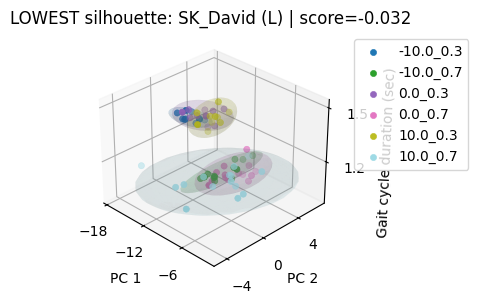

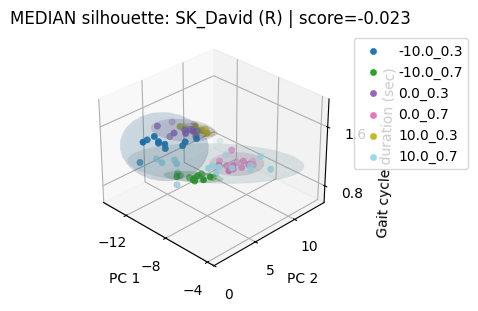

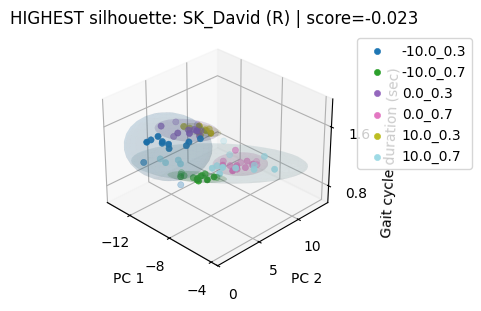

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import chi2
from sklearn.metrics import silhouette_score

# Collect all 18 subject-side cases and compute silhouette scores.
def _to_xyz_case(points_3d):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            arr = np.fromstring(p.strip("[]").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.asarray(parsed, dtype=float)

def _build_case(subject, side):
    if side == "L":
        pts = _to_xyz_case(input_reduced_L['pc_buffer'][subject])
        labels = np.array([
            f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}"
            for i in range(len(spd_idx_L['pc_buffer'][subject]))
        ], dtype=str)
    else:
        pts = _to_xyz_case(input_reduced_R['pc_buffer'][subject])
        labels = np.array([
            f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}"
            for i in range(len(spd_idx_R['pc_buffer'][subject]))
        ], dtype=str)

    n = min(len(pts), len(labels))
    pts = pts[:n]
    labels = labels[:n]

    if n < 4 or np.unique(labels).size < 2:
        return None

    score = float(silhouette_score(pts, labels))
    return {
        "subject": subject,
        "side": side,
        "score": score,
        "pts": pts,
        "labels": labels,
    }

all_cases = []
for subject in subjects:
    for side in ["L", "R"]:
        case = _build_case(subject, side)
        if case is not None:
            all_cases.append(case)

if len(all_cases) == 0:
    raise ValueError("No valid subject-side cases found for silhouette analysis.")

# Print all silhouette scores and summary stats.
score_table = pd.DataFrame([
    {
        "subject": case["subject"],
        "side": case["side"],
        "silhouette": case["score"],
    }
    for case in sorted(all_cases, key=lambda x: (x["subject"], x["side"]))
])

print(f"Silhouette scores for all valid cases (n={len(score_table)}):")
display(score_table)

score_values = score_table["silhouette"].to_numpy(dtype=float)
print(f"Mean silhouette score: {np.mean(score_values):.4f}")
print(f"Std silhouette score: {np.std(score_values):.4f}")

all_cases_sorted = sorted(all_cases, key=lambda x: x["score"])
mid_idx = len(all_cases_sorted) // 2
selected_cases = [
    ("lowest", all_cases_sorted[0]),
    ("median", all_cases_sorted[mid_idx]),
    ("highest", all_cases_sorted[-1]),
]

summary_df = pd.DataFrame([
    {
        "rank": rank_name,
        "subject": case["subject"],
        "side": case["side"],
        "silhouette": case["score"],
        "n_points": len(case["pts"]),
        "n_tasks": int(np.unique(case["labels"]).size),
    }
    for rank_name, case in selected_cases
])
print("Selected representative cases from 18 subject-side combinations:")
display(summary_df)

CHI2_90_DF3 = chi2.ppf(0.90, df=3)

# Plotly helper.
def _add_plotly_confidence_ellipsoid(fig, pts_cluster, color, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 32)
    v = np.linspace(0, np.pi, 16)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, len(u), len(v))
    xe = ellipsoid[0] + center[0]
    ye = ellipsoid[1] + center[1]
    ze = ellipsoid[2] + center[2]

    fig.add_trace(
        go.Surface(
            x=xe,
            y=ye,
            z=ze,
            showscale=False,
            opacity=0.16,
            surfacecolor=np.zeros_like(xe),
            colorscale=[[0, color], [1, color]],
            hoverinfo="skip",
            showlegend=False,
        )
    )

# Matplotlib helper.
def _add_mpl_confidence_ellipsoid(ax, pts_cluster, color, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 15)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, *x.shape)
    ax.plot_surface(
        ellipsoid[0] + center[0],
        ellipsoid[1] + center[1],
        (ellipsoid[2] + center[2]) / 100,
        color=color,
        alpha=0.10,
        linewidth=0,
    )

# Render selected cases in both Plotly and Matplotlib.
for rank_name, case in selected_cases:
    subject = case["subject"]
    side = case["side"]
    score = case["score"]
    pts = case["pts"]
    labels = case["labels"]

    unique_tasks = np.unique(labels)
    cmap = plt.get_cmap("tab20", len(unique_tasks))
    task_to_color_mpl = {task: cmap(i) for i, task in enumerate(unique_tasks)}
    task_to_color_hex = {
        task: "#{:02x}{:02x}{:02x}".format(
            int(255 * task_to_color_mpl[task][0]),
            int(255 * task_to_color_mpl[task][1]),
            int(255 * task_to_color_mpl[task][2]),
        )
        for task in unique_tasks
    }

    # Plotly figure.
    fig_plotly = go.Figure()
    for task in unique_tasks:
        mask = labels == task
        cluster = pts[mask]
        color_hex = task_to_color_hex[task]

        fig_plotly.add_trace(
            go.Scatter3d(
                x=cluster[:, 0],
                y=cluster[:, 1],
                z=cluster[:, 2],
                mode="markers",
                name=str(task),
                marker=dict(size=5, color=color_hex, symbol="circle" if side == "L" else "diamond"),
            )
        )
        _add_plotly_confidence_ellipsoid(fig_plotly, cluster, color_hex)

    fig_plotly.update_layout(
        title=f"{rank_name.upper()} silhouette: {subject} ({side}) | score={score:.3f}",
        scene=dict(
            xaxis_title="PC 1",
            yaxis_title="PC 2",
            zaxis_title="Gait cycle duration (sec)",
        ),
        width=700,
        height=550,
    )
    fig_plotly.show()

    # Matplotlib figure.
    fig_mpl = plt.figure(figsize=(4, 3))
    ax = fig_mpl.add_subplot(111, projection="3d")

    for task in unique_tasks:
        mask = labels == task
        cluster = pts[mask]
        color = task_to_color_mpl[task]

        ax.scatter(
            cluster[:, 0],
            cluster[:, 1],
            cluster[:, 2] / 100,
            color=color,
            marker="o",
            s=20,
            edgecolors=color,
            linewidth=0.4,
            label=str(task),
        )
        _add_mpl_confidence_ellipsoid(ax, cluster, color)

    handles, plot_labels = ax.get_legend_handles_labels()
    by_label = dict(zip(plot_labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_title(f"{rank_name.upper()} silhouette: {subject} ({side}) | score={score:.3f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Gait cycle duration (sec)")
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=2))
    ax.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.rcParams['pdf.fonttype'] = 42

    if rank_name == "lowest":
        plt.savefig('Manifold_SK_L.pdf', dpi=300)
    elif rank_name == "highest":
        plt.savefig('Manifold_SK_H.pdf', dpi=300)
    elif rank_name == "median":
        plt.savefig('Manifold_SK_M.pdf', dpi=300)
    plt.show()

In [10]:
import plotly.graph_objects as go

cmap = plt.get_cmap("tab20", 18)
palette = [
    "#{:02x}{:02x}{:02x}".format(
        int(255 * cmap(i)[0]), int(255 * cmap(i)[1]), int(255 * cmap(i)[2])
    )
    for i in range(18)
]

def _to_xyz(points_3d):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            # robust for both "[x y z]" and "[x, y, z]"
            arr = np.fromstring(p.strip("()").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.array(parsed, dtype=float)

# pts_L = _to_xyz(input_reduced_L)
# pts_R = _to_xyz(input_reduced_R)
pts_L = _to_xyz(grid_key_L['pc_buffer'][subject])
pts_R = _to_xyz(grid_key_R['pc_buffer'][subject])

# Build labels and convert to numpy arrays (important for boolean masking)
labels_L = np.array([f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}" for i in range(len(spd_idx_L['pc_buffer'][subject]))], dtype=str)
labels_R = np.array([f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}" for i in range(len(spd_idx_R['pc_buffer'][subject]))], dtype=str)

all_labels = np.concatenate([labels_L, labels_R])
unique_tasks = np.unique(all_labels)

task_to_color = {task: palette[i % len(palette)] for i, task in enumerate(unique_tasks)}

fig = go.Figure()

for side, pts, labels, symbol in [
    ("L", pts_L, labels_L, "circle"),
    ("R", pts_R, labels_R, "diamond"),
]:
    n = min(len(pts), len(labels))
    if n == 0:
        continue

    pts_side = pts[:n]
    labels_side = labels[:n]

    for task in unique_tasks:
        mask = labels_side == task
        if not np.any(mask):
            continue

        idx = np.where(mask)[0]
        color = task_to_color[task]

        fig.add_trace(
            go.Scatter3d(
                x=pts_side[mask, 0],
                y=pts_side[mask, 1],
                z=pts_side[mask, 2],
                mode="markers+text",
                # text=idx.astype(str),
                textposition="top center",
                name=f"{task} ({side})",
                marker=dict(size=6, color=color, symbol=symbol),
            )
        )

fig.update_layout(
    title="Sequential 3D points with index labels",
    scene=dict(xaxis_title="PC 1 (/2)", yaxis_title="PC 2 (/2)", zaxis_title="Gait cycle duration (sec) (/10)"),
    width=1500,
    height=1000,
)
fig.show()

# Categorize points by task and calculate shiloutte score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(all_labels)

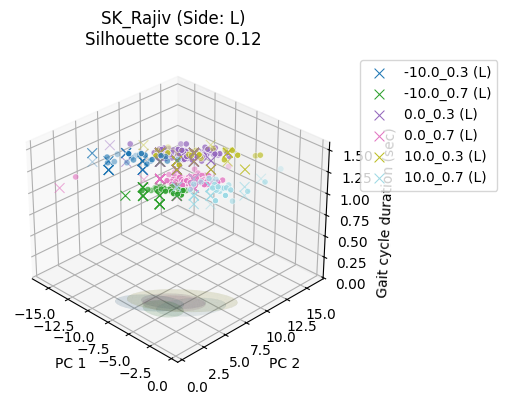

In [121]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- USER SETTINGS ---
side = 'L'  # Change to 'L' or 'R' here
# ---------------------

# Categorize pts_L according to label_L
categorized_pts_L = {
    label: pts_L[labels_L == label]
    for label in np.unique(labels_L)
}
categorized_pts_R = {
    label: pts_R[labels_R == label]
    for label in np.unique(labels_R)
}

# 1. Data Selection Logic
if side.upper() == 'R':
    pts = pts_R
    labels = labels_R
    cat_pts = categorized_pts_R
    marker = 'x'  # Diamond for Right
else:
    pts = pts_L
    labels = labels_L
    cat_pts = categorized_pts_L
    marker = 'x'  # Circle for Left

# Re-calculate unique tasks for this side only
unique_tasks = np.unique(labels)
cmap = plt.get_cmap("tab20", len(unique_tasks))
task_to_color = {task: cmap(i) for i, task in enumerate(unique_tasks)}

# 2. Setup Figure and 3D Axis
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot Scatter Points for the selected side
n = min(len(pts), len(labels))
pts_final_disc = pts[:n]
labels_final = labels[:n]

for task in unique_tasks:
    mask = labels_final == task
    if not np.any(mask): continue

    ax.scatter(
        pts_final[mask, 0], 
        pts_final[mask, 1], 
        pts_final[mask, 2]/100,
        color=task_to_color[task],
        marker='o',
        s=20,
        edgecolors='white',
        linewidth=0.5,
        label=f"{task} ({side})"
    )

    ax.scatter(
        pts_final_disc[mask, 0]*2, 
        pts_final_disc[mask, 1]*2, 
        pts_final_disc[mask, 2]*10/100,
        color=task_to_color[task],
        marker=marker,
        s=50,
        linewidth=0.75,
        label=f"{task} ({side})"
    )

# 4. Add Ellipsoids for the selected side
for label, pts_cluster in cat_pts.items():
    _add_mpl_ellipsoid(ax, pts_cluster, task_to_color[label])

# 5. Final Formatting
if side == 'L':
    silhouette_score = overall_silhouette_L
else:
    silhouette_score = overall_silhouette_R

ax.set_title(f"{subject} (Side: {side})\nSilhouette score {silhouette_score:.2f}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("Gait cycle duration (sec)")

# Legend management (only show one entry per task)
handles, plot_labels = ax.get_legend_handles_labels()
by_label = dict(zip(plot_labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax.view_init(elev=30, azim=-45)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
pca_model_file = '/home/metamobility5/Changseob/proj-online_adaptation_GPE/method-replay_buffer/pca_model_pos_1gc_2_50.pkl'
with open(pca_model_file, 'rb') as f:
    pca_data = pickle.load(f)
    
pca_matrix = pca_data['pca_matrix']
print(f"PCA matrix shape loaded: {pca_matrix.shape}")
scaler_mean = pca_data['scaler_mean']
scaler_scale = pca_data['scaler_scale']

In [ ]:
course = 3; inc = 'RD_5'; side = 'R'; ex_cycle = 70

mtr_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_motor.csv')
hs_indices_L = detect_heel_strike(mtr_data[:, 5], threshold=0.1, min_interval=90, max_interval=210, side='L')
hs_indices_R = detect_heel_strike(mtr_data[:, 6], threshold=0.1, min_interval=90, max_interval=210, side='R')
print(len(hs_indices_L), len(hs_indices_R))

if side == 'L':
    example_data = mtr_data[hs_indices_L[ex_cycle]:hs_indices_L[ex_cycle+1], 1:3].T  # Take pos_L and pos_R
else:
    example_data = mtr_data[hs_indices_R[ex_cycle]:hs_indices_R[ex_cycle+1], 1:3].T

example_data = upsampling_2d(example_data, target_length=50)  # Upsample to 50 time steps
example_data = example_data.flatten()
# Scale and reduce example data

print(example_data.shape, scaler_mean.shape, scaler_scale.shape)
example_data_scaled = (example_data - scaler_mean) / scaler_scale
example_data_reduced = np.dot(example_data_scaled, pca_matrix)

# Reconstruct example data
example_data_reconstructed_std = np.dot(example_data_reduced, pca_matrix.T)
example_data_reconstructed = example_data_reconstructed_std * scaler_scale + scaler_mean

# Calculate reconstruction error
reconstruction_error = np.sqrt(np.mean((example_data_scaled - example_data_reconstructed_std) ** 2))
print(f"Reconstruction RMSE (Scaled): {reconstruction_error:.3f}")

plot_reconstruction_mtr(example_data, example_data_reconstructed)

# PCA method figure for SK

In [ ]:
condition = 'pc_buffer'
task_list = ['LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast']
task_PC_L = {task: [] for task in task_list}
task_PC_R = {task: [] for task in task_list}

for task in task_list:
    for subject in ['SK_Maria']:
        task_PC_L[task].extend(input_reduced_PC_L[condition][subject][task])
        task_PC_R[task].extend(input_reduced_PC_R[condition][subject][task])
    print(f"Total samples for {task} in PC buffer \t (Left): {len(task_PC_L[task])},\t (Right): {len(task_PC_R[task])}")

from sklearn.metrics import silhouette_score
from scipy.stats import chi2

def parse_points(raw_points):
    parsed = []
    for s in raw_points:
        if isinstance(s, str):
            arr = np.fromstring(s.strip().strip('[]'), sep=' ')
        else:
            arr = np.asarray(s, dtype=float).ravel()
        if arr.size == 3 and np.all(np.isfinite(arr)):
            parsed.append(arr)
    return np.vstack(parsed).astype(float) if parsed else np.empty((0, 3), dtype=float)

def plot_confidence_ellipsoid(ax, points, color, conf=0.99, alpha=0.12, resolution=30):
    if points.shape[0] < 4:
        return

    mean = points.mean(axis=0)
    cov = np.cov(points, rowvar=False)
    cov = cov + 1e-8 * np.eye(3)

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-8, None)

    scale = np.sqrt(chi2.ppf(conf, df=3))
    radii = scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)
    ellipsoid = eigvecs @ np.diag(radii) @ sphere
    ellipsoid = ellipsoid + mean[:, None]

    X = ellipsoid[0].reshape(resolution, resolution)
    Y = ellipsoid[1].reshape(resolution, resolution)
    Z = ellipsoid[2].reshape(resolution, resolution)

    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, linewidth=0, shade=True)

def build_task_arrays(task_pc_dict):
    task_arrays = {task: parse_points(task_pc_dict[task]) for task in task_list}
    nonempty_tasks = [task for task, data in task_arrays.items() if data.shape[0] > 0]

    all_points = (
        np.vstack([task_arrays[task] for task in nonempty_tasks])
        if nonempty_tasks else np.empty((0, 3), dtype=float)
    )
    all_labels = (
        np.concatenate([np.repeat(task, len(task_arrays[task])) for task in nonempty_tasks])
        if nonempty_tasks else np.array([], dtype=str)
    )
    return task_arrays, all_points, all_labels

def plot_side_task_space(ax, task_pc_dict, side_name, colors):
    task_arrays, all_points, all_labels = build_task_arrays(task_pc_dict)
    valid_tasks = [task for task, data in task_arrays.items() if data.shape[0] >= 2]

    if len(valid_tasks) >= 2:
        valid_mask = np.isin(all_labels, valid_tasks)
        sil_score = silhouette_score(all_points[valid_mask], all_labels[valid_mask])
        print(f"Silhouette score ({side_name}) = {sil_score:.4f}")
    else:
        sil_score = np.nan
        print(f"Not enough valid clusters to compute silhouette score for {side_name}.")

    for color, task in zip(colors, task_list):
        data = task_arrays[task]
        if data.shape[0] == 0:
            continue

        ax.scatter(
            data[:, 0], data[:, 1], data[:, 2],
            s=20, alpha=0.7, color=color, label=task
        )
        plot_confidence_ellipsoid(ax, data, color=color, conf=0.90)

    ax.set_title(f'{side_name} silhouette = {sil_score:.2f}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('Gait cycle duration (s)')
    ax.legend()
    ax.grid(True)

    return all_points

plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for editable PDF text
colors = plt.cm.tab10(np.linspace(0, 1, len(task_list)))
side_sources = {'Left': task_PC_L, 'Right': task_PC_R}

fig = plt.figure(figsize=(10, 4))
axes = [fig.add_subplot(1, 2, i + 1, projection='3d') for i in range(2)]

side_points = []
for ax, (side_name, task_pc_dict) in zip(axes, side_sources.items()):
    pts = plot_side_task_space(ax, task_pc_dict, side_name, colors)
    if pts.size > 0:
        side_points.append(pts)
    # ax.view_init(elev=30, azim=45)

if side_points:
    combined_points = np.vstack(side_points)
    x_min, x_max = combined_points[:, 0].min(), combined_points[:, 0].max()
    y_min, y_max = combined_points[:, 1].min(), combined_points[:, 1].max()
    z_min, z_max = combined_points[:, 2].min(), combined_points[:, 2].max()

    x_pad = 0.05 * max(x_max - x_min, 1)
    y_pad = 0.05 * max(y_max - y_min, 1)
    z_pad = 0.05 * max(z_max - z_min, 1)

    for ax in axes:
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_zlim(z_min - z_pad, z_max + z_pad)

plt.tight_layout()
plt.savefig('PCA_SK_both_sides.pdf', dpi=300)
plt.show()